<a href="https://colab.research.google.com/github/ABHI20-STAT/Fractal_and_Research/blob/main/Exterior_Green_Function_of_the_Mandelbrot_Set.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Parameter Green-function range:
    min positive G_M = 1.240233e-13
    max G_M          = 0.803596

Display potential:
    alpha             = 220.0
    display percentile= 98.5
    colourbar maximum = 5.063960

External angles plotted:
    theta = $1/6$ = 0.16666667 turns
    theta = $1/4$ = 0.25000000 turns
    theta = $1/3$ = 0.33333333 turns
    theta = $2/3$ = 0.66666667 turns
    theta = $3/4$ = 0.75000000 turns
    theta = $5/6$ = 0.83333333 turns


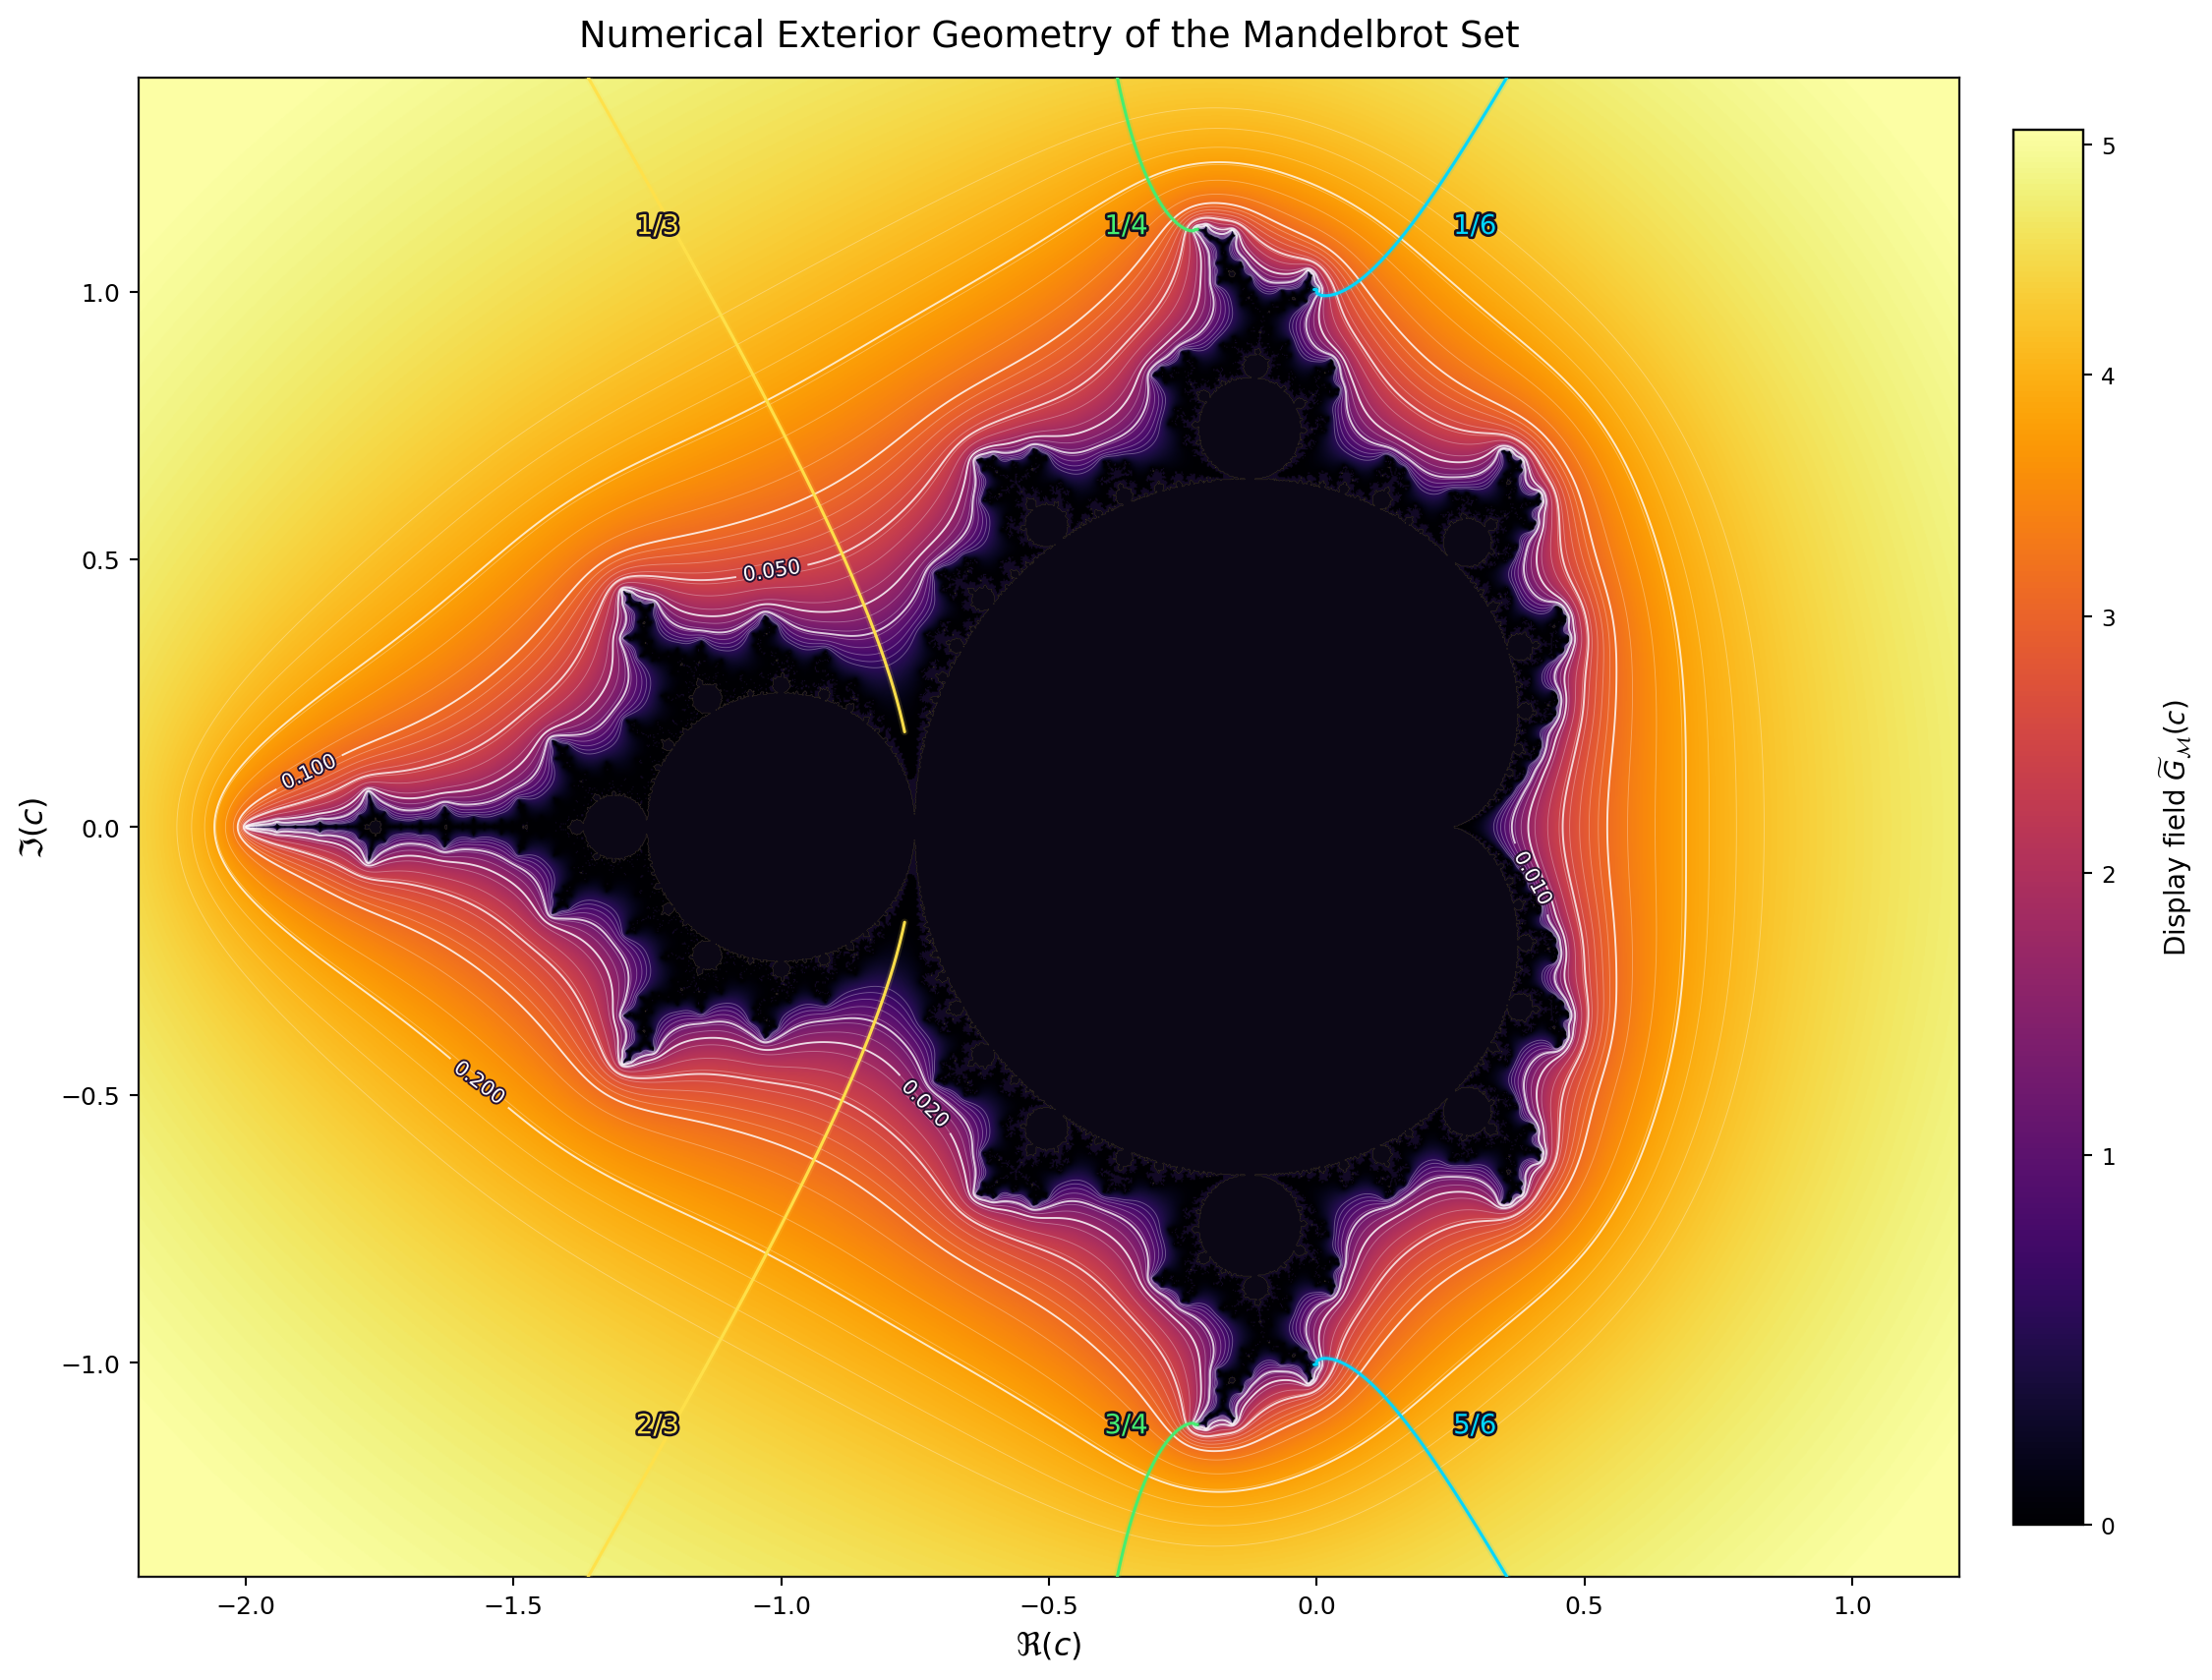

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from matplotlib.patheffects import withStroke


# =============================================================================
# Numerical exterior geometry of the Mandelbrot set
# Green-function equipotentials and numerical parameter rays
# =============================================================================

# This script computes a finite-resolution approximation of:
#
#   1. the Mandelbrot exterior,
#   2. the parameter Green function
#          G_M(c)=log|Phi_M(c)|,
#   3. selected parameter external rays
#          arg Phi_M(c)=2*pi*theta.
#
# The Green function and external angle are computed from a truncated logarithmic
# Böttcher-coordinate expansion. The coloured background uses only a display
# transformation of G_M; the white contours are level sets of the untransformed
# Green function G_M.


# =============================================================================
# 1. COMPUTATIONAL PARAMETERS
# =============================================================================

width, height = 1700, 1300

xmin, xmax = -2.2, 1.2
ymin, ymax = -1.4, 1.4

max_iter = 650
escape_radius = 200.0

# Number of terms used in the logarithmic Böttcher expansion.
bottcher_terms = 30

# Display transformation:
#
#     \widetilde{G}_M(c)=log(1+alpha G_M(c)).
#
# This is used only for the coloured background.  The equipotential contours
# are drawn using the untransformed Green function G_M.
display_alpha = 220.0

# Colour saturation control for the display field.
# Smaller percentile reduces far-exterior yellow saturation.
display_percentile = 98.5

# Raw G_M contour levels. These are in the parameter-Green-function
# normalization
#
#     G_M(c)=log|Phi_M(c)|=2g_c(0).
#
# The levels are chosen to show detail near the boundary without overwhelming
# the figure.
dense_equipotential_levels = np.unique(
    np.concatenate([
        np.geomspace(0.003, 0.020, 8),
        np.linspace(0.025, 0.100, 8),
        np.linspace(0.125, 0.300, 6),
    ])
)

# Label only selected contours to avoid clutter.
label_levels = [
    0.010,
    0.020,
    0.050,
    0.100,
    0.200,
]

# External angles measured in turns.
# Conjugate angle pairs use the same colour.
ray_specs = [
    (1 / 6, r"$1/6$", "#00d7ff"),
    (1 / 4, r"$1/4$", "#44ee70"),
    (1 / 3, r"$1/3$", "#ffe14a"),
    (2 / 3, r"$2/3$", "#ffe14a"),
    (3 / 4, r"$3/4$", "#44ee70"),
    (5 / 6, r"$5/6$", "#00d7ff"),
]

# Interior colour for the numerical Mandelbrot set.
# This is deliberately not pure black.  The region represents G_M=0, so it
# should remain dark and low-energy, but not visually overpower the exterior.
mandelbrot_fill_colour = "#0b0715"

# Boundary highlight colour.  Kept subdued to avoid visual noise.
mandelbrot_boundary_colour = "#d8c14a"


# =============================================================================
# 2. ESCAPE MASK
# =============================================================================

def compute_mandelbrot_escape_grid(C, max_iter=650, escape_radius=200.0):
    """
    Compute a finite-iteration Mandelbrot escape mask using the critical orbit

        z_0 = 0,
        z_{n+1}=z_n^2+c.

    Returns
    -------
    escaped : bool ndarray
        True for points whose critical orbit escaped before max_iter.

    escape_iteration : int ndarray
        First escape time for escaped points; max_iter otherwise.
    """

    Z = np.zeros_like(C, dtype=np.complex128)

    escaped = np.zeros(C.shape, dtype=bool)

    escape_iteration = np.full(
        C.shape,
        max_iter,
        dtype=np.int32
    )

    for n in range(1, max_iter + 1):
        active = ~escaped

        if not np.any(active):
            break

        Z[active] = Z[active] * Z[active] + C[active]

        newly_escaped = active & (np.abs(Z) > escape_radius)

        if np.any(newly_escaped):
            escape_iteration[newly_escaped] = n
            escaped[newly_escaped] = True

            # Avoid overflow in later iterations.
            Z[newly_escaped] = 0.0

    return escaped, escape_iteration


# =============================================================================
# 3. LOGARITHMIC PARAMETER BÖTTCHER APPROXIMATION
# =============================================================================

def compute_log_parameter_bottcher(C, exterior_mask, bottcher_terms=30):
    """
    Approximate

        L(c)=log Phi_M(c)

    on the numerical exterior of the Mandelbrot set.

    For c outside M, the parameter Böttcher coordinate satisfies

        Phi_M(c)=phi_c(c).

    With z_0=c and z_{k+1}=z_k^2+c, one obtains formally

        log Phi_M(c)
        =
        log c
        +
        sum_{k>=0} 2^{-(k+1)} log(1+c/z_k^2).

    The principal branch of log fixes the normalization

        Phi_M(c)/c -> 1

    as c -> infinity.
    """

    log_phi = np.full(
        C.shape,
        np.nan + 1j * np.nan,
        dtype=np.complex128
    )

    c_ext = C[exterior_mask].astype(np.complex128, copy=True)
    z_ext = c_ext.copy()

    # Principal logarithm at infinity.
    L_ext = np.log(c_ext)

    active_series = np.ones(c_ext.shape, dtype=bool)

    overflow_threshold = 1.0e80
    small_denominator_threshold = 1.0e-300

    for k in range(bottcher_terms):
        ids = np.flatnonzero(active_series)

        if ids.size == 0:
            break

        z_current = z_ext[ids]
        c_current = c_ext[ids]

        denominator = z_current * z_current

        safe = np.abs(denominator) > small_denominator_threshold

        if np.any(safe):
            safe_ids = ids[safe]
            ratio = c_current[safe] / denominator[safe]

            L_ext[safe_ids] += (
                np.log1p(ratio)
                / (2.0 ** (k + 1))
            )

        if np.any(~safe):
            unsafe_ids = ids[~safe]
            active_series[unsafe_ids] = False

        z_next = z_current * z_current + c_current
        z_ext[ids] = z_next

        finite_next = (
            np.isfinite(z_next.real)
            & np.isfinite(z_next.imag)
        )

        bounded_next = np.abs(z_next) < overflow_threshold

        active_series[ids] &= finite_next & bounded_next

    log_phi[exterior_mask] = L_ext

    return log_phi


# =============================================================================
# 4. RAY-SEGMENT UTILITIES
# =============================================================================

def segment_arc_length(segment):
    """
    Euclidean arc length of a polyline segment.
    """

    if len(segment) < 2:
        return 0.0

    differences = np.diff(segment, axis=0)

    return np.sum(
        np.hypot(
            differences[:, 0],
            differences[:, 1]
        )
    )


def touches_plot_boundary(
    segment,
    xmin,
    xmax,
    ymin,
    ymax,
    tolerance=0.030
):
    """
    Check whether a contour segment touches the plotting frame.
    """

    sx = segment[:, 0]
    sy = segment[:, 1]

    return np.any(
        (np.abs(sx - xmin) < tolerance)
        | (np.abs(sx - xmax) < tolerance)
        | (np.abs(sy - ymin) < tolerance)
        | (np.abs(sy - ymax) < tolerance)
    )


def distance_to_frame(point, xmin, xmax, ymin, ymax):
    """
    Minimum distance from a point to the rectangular plotting frame.
    """

    px, py = point

    return min(
        abs(px - xmin),
        abs(px - xmax),
        abs(py - ymin),
        abs(py - ymax)
    )


def choose_main_ray_segment(segments, xmin, xmax, ymin, ymax):
    """
    Select the principal ray component.

    Preference is given to long segments that enter through the plotting frame.
    """

    candidates = [
        segment
        for segment in segments
        if (
            len(segment) >= 10
            and touches_plot_boundary(segment, xmin, xmax, ymin, ymax)
        )
    ]

    if not candidates:
        candidates = [
            segment
            for segment in segments
            if len(segment) >= 10
        ]

    if not candidates:
        return None

    return max(
        candidates,
        key=segment_arc_length
    )


def orient_from_outer_boundary(segment, xmin, xmax, ymin, ymax):
    """
    Orient a ray from the outer frame toward the Mandelbrot set.
    """

    d0 = distance_to_frame(
        segment[0],
        xmin,
        xmax,
        ymin,
        ymax
    )

    d1 = distance_to_frame(
        segment[-1],
        xmin,
        xmax,
        ymin,
        ymax
    )

    if d0 <= d1:
        return segment

    return segment[::-1]


def safe_label_position(
    segment,
    xmin,
    xmax,
    ymin,
    ymax,
    fraction=0.20
):
    """
    Place a ray label safely inside the panel.

    The fraction parameter moves labels inward along the ray, reducing boundary
    collisions and improving association with the visible ray curve.
    """

    number_of_points = len(segment)

    index = int(fraction * number_of_points)

    index = np.clip(
        index,
        10,
        number_of_points - 2
    )

    px, py = segment[index]

    x_margin = 0.10 * (xmax - xmin)
    y_margin = 0.10 * (ymax - ymin)

    px = np.clip(
        px,
        xmin + x_margin,
        xmax - x_margin
    )

    py = np.clip(
        py,
        ymin + y_margin,
        ymax - y_margin
    )

    return px, py


def remove_contour(contour_set):
    """
    Remove a temporary Matplotlib contour set.
    """

    try:
        contour_set.remove()
    except AttributeError:
        for collection in contour_set.collections:
            collection.remove()


# =============================================================================
# 5. MAIN FIGURE ROUTINE
# =============================================================================

def make_mandelbrot_exterior_geometry_figure(
    output_png="mandelbrot_green_equipotentials_parameter_rays_indigo.png",
    output_pdf="mandelbrot_green_equipotentials_parameter_rays_indigo.pdf",
):
    """
    Generate a publication-style numerical visualization of the Mandelbrot
    exterior geometry: Green-function equipotentials and parameter external rays.
    """

    # -------------------------------------------------------------------------
    # Grid
    # -------------------------------------------------------------------------

    x = np.linspace(xmin, xmax, width)
    y = np.linspace(ymin, ymax, height)

    X, Y = np.meshgrid(x, y)
    C = X + 1j * Y

    # -------------------------------------------------------------------------
    # Escape mask
    # -------------------------------------------------------------------------

    escaped, escape_iteration = compute_mandelbrot_escape_grid(
        C,
        max_iter=max_iter,
        escape_radius=escape_radius
    )

    inside = ~escaped

    exterior_mask = (
        escaped
        & (np.abs(C) > 1.0e-14)
    )

    # -------------------------------------------------------------------------
    # Böttcher logarithm
    # -------------------------------------------------------------------------

    log_phi = compute_log_parameter_bottcher(
        C,
        exterior_mask=exterior_mask,
        bottcher_terms=bottcher_terms
    )

    G_M = np.full(
        C.shape,
        np.nan,
        dtype=float
    )

    G_M[exterior_mask] = np.real(
        log_phi[exterior_mask]
    )

    # Numerical roundoff correction near the boundary.
    G_M[exterior_mask] = np.maximum(
        G_M[exterior_mask],
        0.0
    )

    theta_field = np.full(
        C.shape,
        np.nan,
        dtype=float
    )

    theta_field[exterior_mask] = np.mod(
        np.imag(log_phi[exterior_mask]) / (2.0 * np.pi),
        1.0
    )

    positive = (
        exterior_mask
        & np.isfinite(G_M)
        & (G_M > 0)
    )

    # -------------------------------------------------------------------------
    # Display potential
    # -------------------------------------------------------------------------

    G_tilde = np.full(
        C.shape,
        np.nan,
        dtype=float
    )

    G_tilde[positive] = np.log1p(
        display_alpha * G_M[positive]
    )

    display_vmin = 0.0

    display_vmax = np.nanpercentile(
        G_tilde[positive],
        display_percentile
    )

    G_tilde = np.clip(
        G_tilde,
        display_vmin,
        display_vmax
    )

    # -------------------------------------------------------------------------
    # Figure style
    # -------------------------------------------------------------------------

    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "mathtext.fontset": "dejavusans",
        "axes.linewidth": 0.9,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 9.5,
        "ytick.labelsize": 9.5
    })

    fig, ax = plt.subplots(
        figsize=(12.2, 9.1),
        dpi=190,
        facecolor="white"
    )

    ax.set_facecolor("#120925")

    # -------------------------------------------------------------------------
    # Background display field
    # -------------------------------------------------------------------------

    im = ax.imshow(
        G_tilde,
        extent=[
            xmin,
            xmax,
            ymin,
            ymax
        ],
        origin="lower",
        cmap="inferno",
        interpolation="bilinear",
        aspect="equal",
        norm=PowerNorm(
            gamma=0.82,
            vmin=display_vmin,
            vmax=display_vmax
        ),
        zorder=1
    )

    # -------------------------------------------------------------------------
    # Equipotential contours
    # -------------------------------------------------------------------------

    available_max = np.nanmax(G_M)

    contour_levels = [
        level
        for level in dense_equipotential_levels
        if 0 < level < available_max
    ]

    ax.contour(
        X,
        Y,
        G_M,
        levels=contour_levels,
        colors="white",
        linewidths=0.34,
        alpha=0.32,
        zorder=4
    )

    valid_label_levels = [
        level
        for level in label_levels
        if level < available_max
    ]

    if valid_label_levels:
        labelled_contours = ax.contour(
            X,
            Y,
            G_M,
            levels=valid_label_levels,
            colors="white",
            linewidths=0.72,
            alpha=0.78,
            zorder=5
        )

        contour_text = ax.clabel(
            labelled_contours,
            inline=True,
            inline_spacing=6,
            fontsize=7.8,
            fmt=lambda value: f"{value:.3f}"
        )

        for text in contour_text:
            text.set_color("white")
            text.set_path_effects([
                withStroke(
                    linewidth=1.45,
                    foreground="#281232"
                )
            ])

    # -------------------------------------------------------------------------
    # Parameter external rays
    # -------------------------------------------------------------------------

    for theta_value, theta_label, ray_colour in ray_specs:
        phase_difference = theta_field - theta_value

        ray_level_function = np.sin(
            2.0 * np.pi * phase_difference
        )

        correct_branch = (
            np.cos(2.0 * np.pi * phase_difference) > 0
        )

        valid_ray_region = (
            exterior_mask
            & correct_branch
            & np.isfinite(ray_level_function)
            & (G_M > 2.0e-5)
        )

        masked_ray_function = np.ma.masked_where(
            ~valid_ray_region,
            ray_level_function
        )

        temporary_contour = ax.contour(
            X,
            Y,
            masked_ray_function,
            levels=[0.0],
            colors=[ray_colour],
            linewidths=0.01,
            alpha=0.0
        )

        segments = temporary_contour.allsegs[0]

        remove_contour(temporary_contour)

        main_segment = choose_main_ray_segment(
            segments,
            xmin,
            xmax,
            ymin,
            ymax
        )

        if main_segment is None:
            print(
                f"Warning: no principal segment found for theta={theta_value}."
            )
            continue

        main_segment = orient_from_outer_boundary(
            main_segment,
            xmin,
            xmax,
            ymin,
            ymax
        )

        ray_x = main_segment[:, 0]
        ray_y = main_segment[:, 1]

        # Soft glow layer.
        ax.plot(
            ray_x,
            ray_y,
            color=ray_colour,
            linewidth=2.8,
            alpha=0.14,
            solid_capstyle="round",
            zorder=6
        )

        # Main ray.
        ax.plot(
            ray_x,
            ray_y,
            color=ray_colour,
            linewidth=1.18,
            alpha=0.98,
            solid_capstyle="round",
            zorder=7
        )

        label_x, label_y = safe_label_position(
            main_segment,
            xmin,
            xmax,
            ymin,
            ymax,
            fraction=0.20
        )

        label_artist = ax.text(
            label_x,
            label_y,
            theta_label,
            color=ray_colour,
            fontsize=10.4,
            fontweight="medium",
            ha="center",
            va="center",
            clip_on=True,
            zorder=10
        )

        label_artist.set_path_effects([
            withStroke(
                linewidth=2.0,
                foreground="#171020"
            )
        ])

    # -------------------------------------------------------------------------
    # Mandelbrot set and boundary
    # -------------------------------------------------------------------------

    # The interior represents G_M=0.  It is therefore kept visually low-energy.
    # A deep indigo is used instead of pure black to avoid a visually dominant
    # central mass while preserving the zero-potential interpretation.
    ax.contourf(
        X,
        Y,
        inside.astype(float),
        levels=[0.5, 1.5],
        colors=[mandelbrot_fill_colour],
        alpha=0.97,
        zorder=8
    )

    # Subdued boundary highlight.
    ax.contour(
        X,
        Y,
        inside.astype(float),
        levels=[0.5],
        colors=[mandelbrot_boundary_colour],
        linewidths=0.14,
        alpha=0.32,
        zorder=9
    )

    # -------------------------------------------------------------------------
    # Axes and title
    # -------------------------------------------------------------------------

    ax.set_title(
        "Numerical Exterior Geometry of the Mandelbrot Set",
        pad=12
    )

    ax.set_xlabel(r"$\Re(c)$")
    ax.set_ylabel(r"$\Im(c)$")

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_aspect(
        "equal",
        adjustable="box"
    )

    ax.set_xticks([
        -2.0,
        -1.5,
        -1.0,
        -0.5,
        0.0,
        0.5,
        1.0
    ])

    ax.set_yticks([
        -1.0,
        -0.5,
        0.0,
        0.5,
        1.0
    ])

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_color("#161616")
        spine.set_linewidth(0.85)

    # -------------------------------------------------------------------------
    # Colourbar
    # -------------------------------------------------------------------------

    cbar = fig.colorbar(
        im,
        ax=ax,
        fraction=0.043,
        pad=0.026,
        shrink=0.93
    )

    cbar.set_label(
        r"Display field $\widetilde{G}_{\mathcal{M}}(c)$",
        fontsize=10.5,
        rotation=90,
        labelpad=16
    )

    cbar.ax.tick_params(
        labelsize=8.8
    )

    # -------------------------------------------------------------------------
    # Numerical consistency report
    # -------------------------------------------------------------------------

    print("Parameter Green-function range:")
    print(f"    min positive G_M = {np.nanmin(G_M[positive]):.6e}")
    print(f"    max G_M          = {np.nanmax(G_M[positive]):.6f}")

    print("\nDisplay potential:")
    print(f"    alpha             = {display_alpha:.1f}")
    print(f"    display percentile= {display_percentile:.1f}")
    print(f"    colourbar maximum = {display_vmax:.6f}")

    print("\nExternal angles plotted:")

    for theta_value, theta_label, _ in ray_specs:
        print(
            f"    theta = {theta_label} "
            f"= {theta_value:.8f} turns"
        )

    # -------------------------------------------------------------------------
    # Save and display
    # -------------------------------------------------------------------------

    plt.tight_layout()

    fig.savefig(
        output_png,
        dpi=450,
        bbox_inches="tight",
        facecolor="white"
    )

    fig.savefig(
        output_pdf,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()


# =============================================================================
# 6. RUN SCRIPT
# =============================================================================

if __name__ == "__main__":
    make_mandelbrot_exterior_geometry_figure()

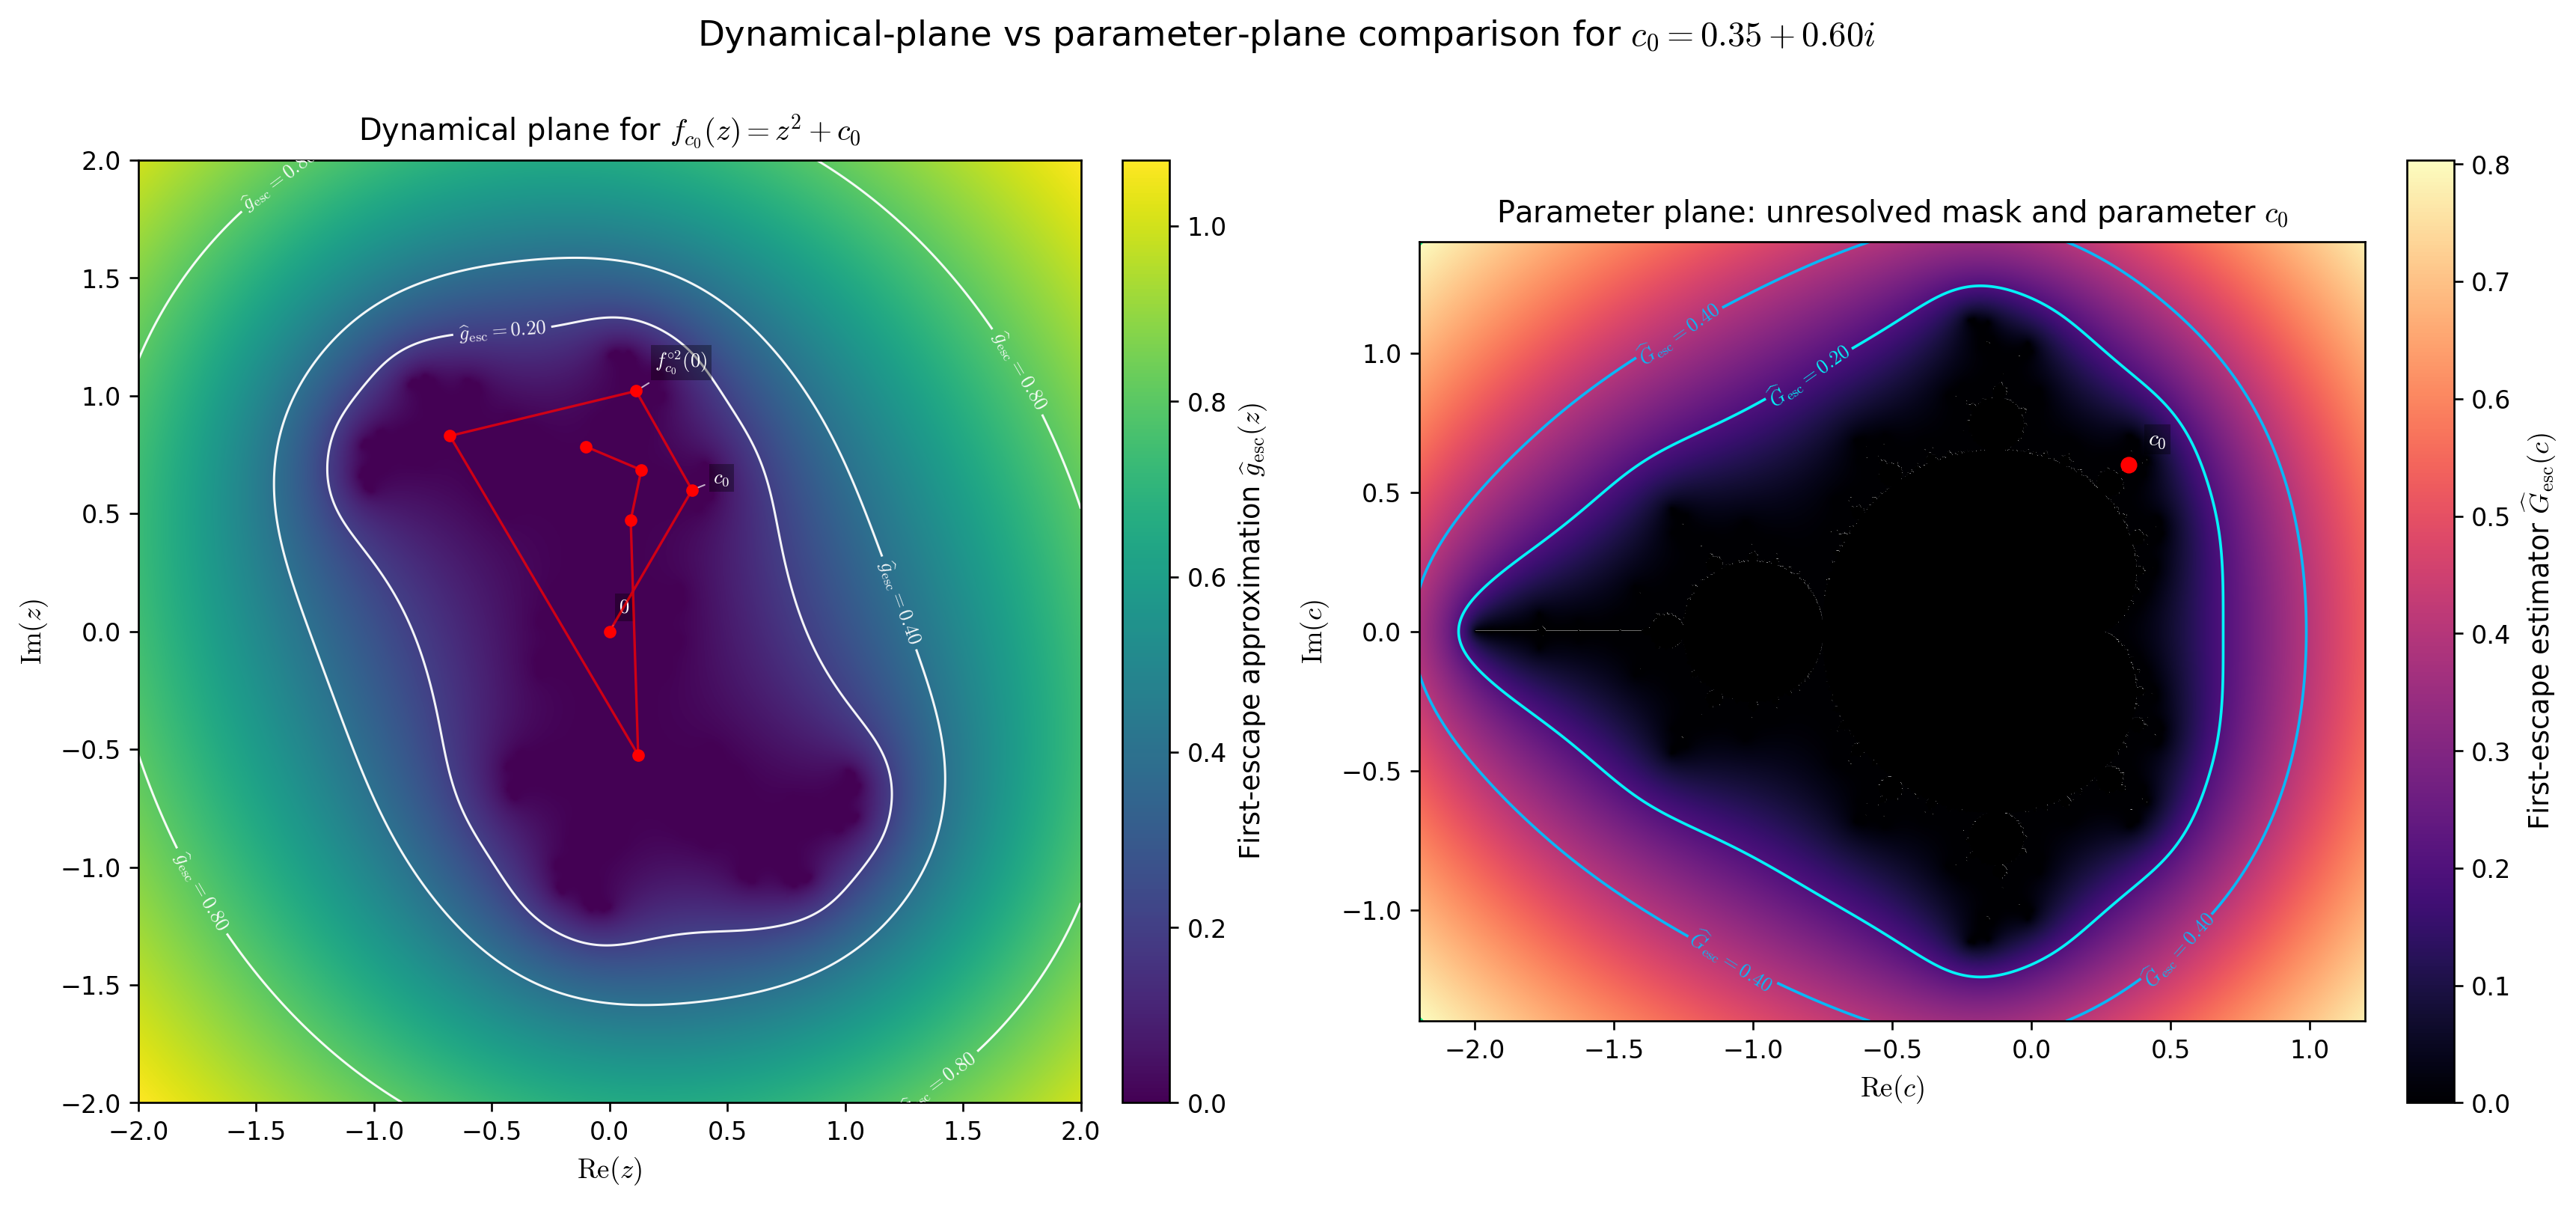

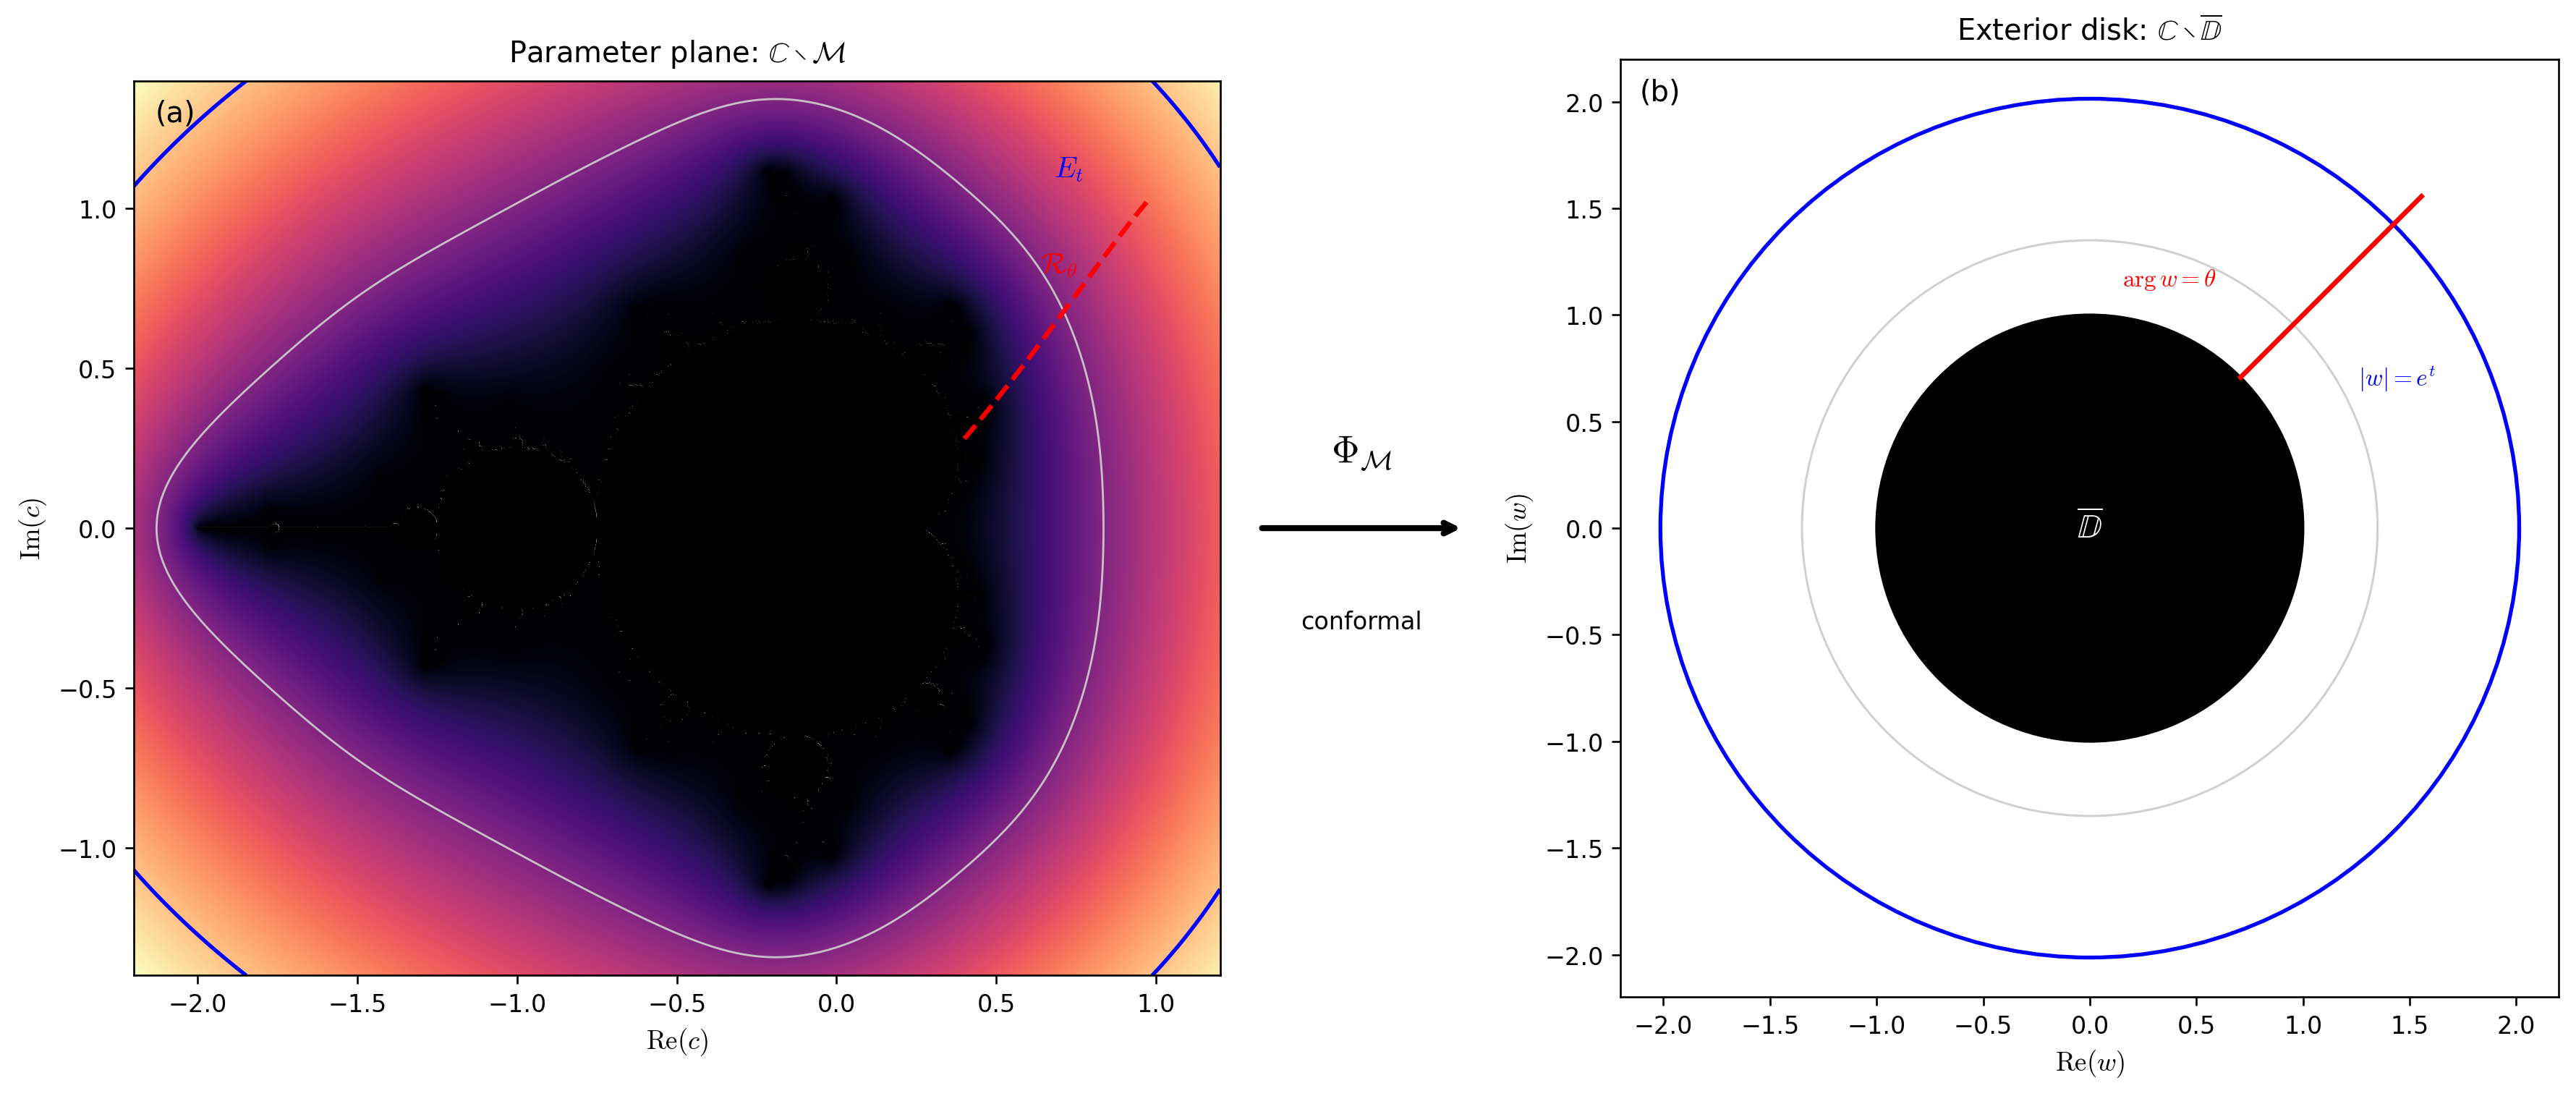

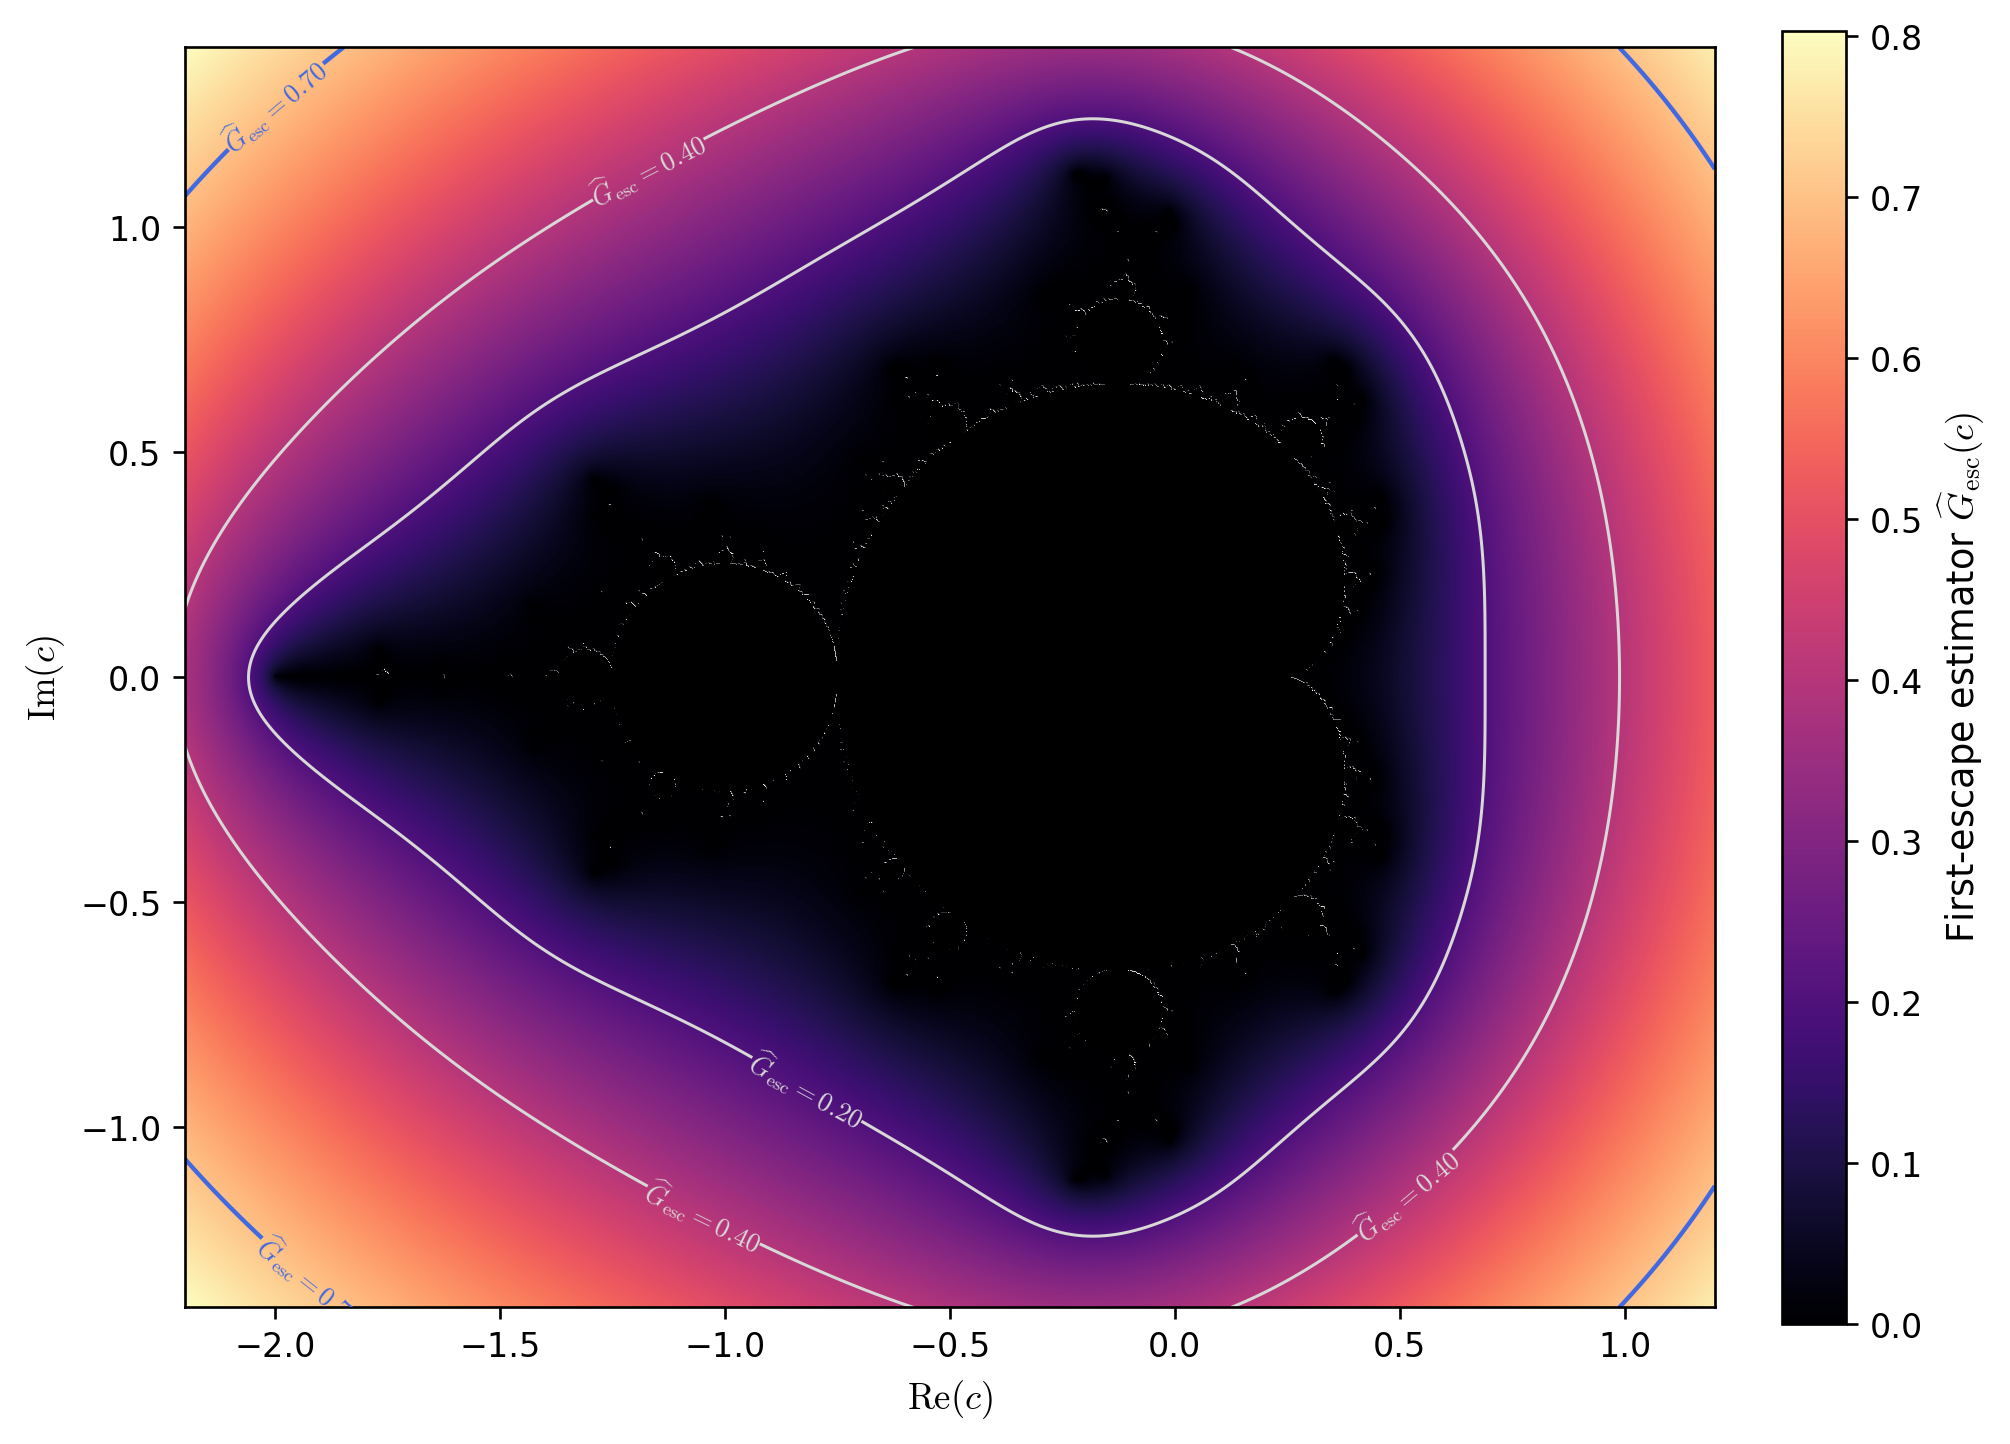

$c_1=0.60+0.20i$: G_ref(c) = 0.133753246897
$c_1=0.60+0.20i$: reference escape time = 8
$c_1=0.60+0.20i$: reference error certificate<= 4.941059e-15
$c_1=0.60+0.20i$: theorem-bound entry time forR=4 is n0=5
$c_1=0.60+0.20i$: discrepancies = [1.33753247e-01 1.23948069e-01 1.48539409e-02 1.98384430e-03
 1.26635535e-04 1.53787869e-06 1.09379422e-10 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
$c_1=0.60+0.20i$: theorem bounds = [           nan            nan            nan            nan
 2.52068368e-03 1.26034184e-03 6.30170919e-04 3.15085459e-04
 1.57542730e-04 7.87713649e-05 3.93856824e-05 1.96928412e-05]
$c_1=0.60+0.20i$: certified comparison bounds = [           nan            nan            nan            nan
 2.52068368e-03 1.26034184e-03 6.30170919e-04 3.15085459e-04
 1.57542730e-04 7.87713649e-05 3.93856824e-05 1.96928412e-05]
$c_2=0.80+0.30i$: G_ref(c) = 0.287741090935
$c_2=0.80+0.30i$: reference escape time = 7
$c_2=0.80+0.30i$: reference error ce

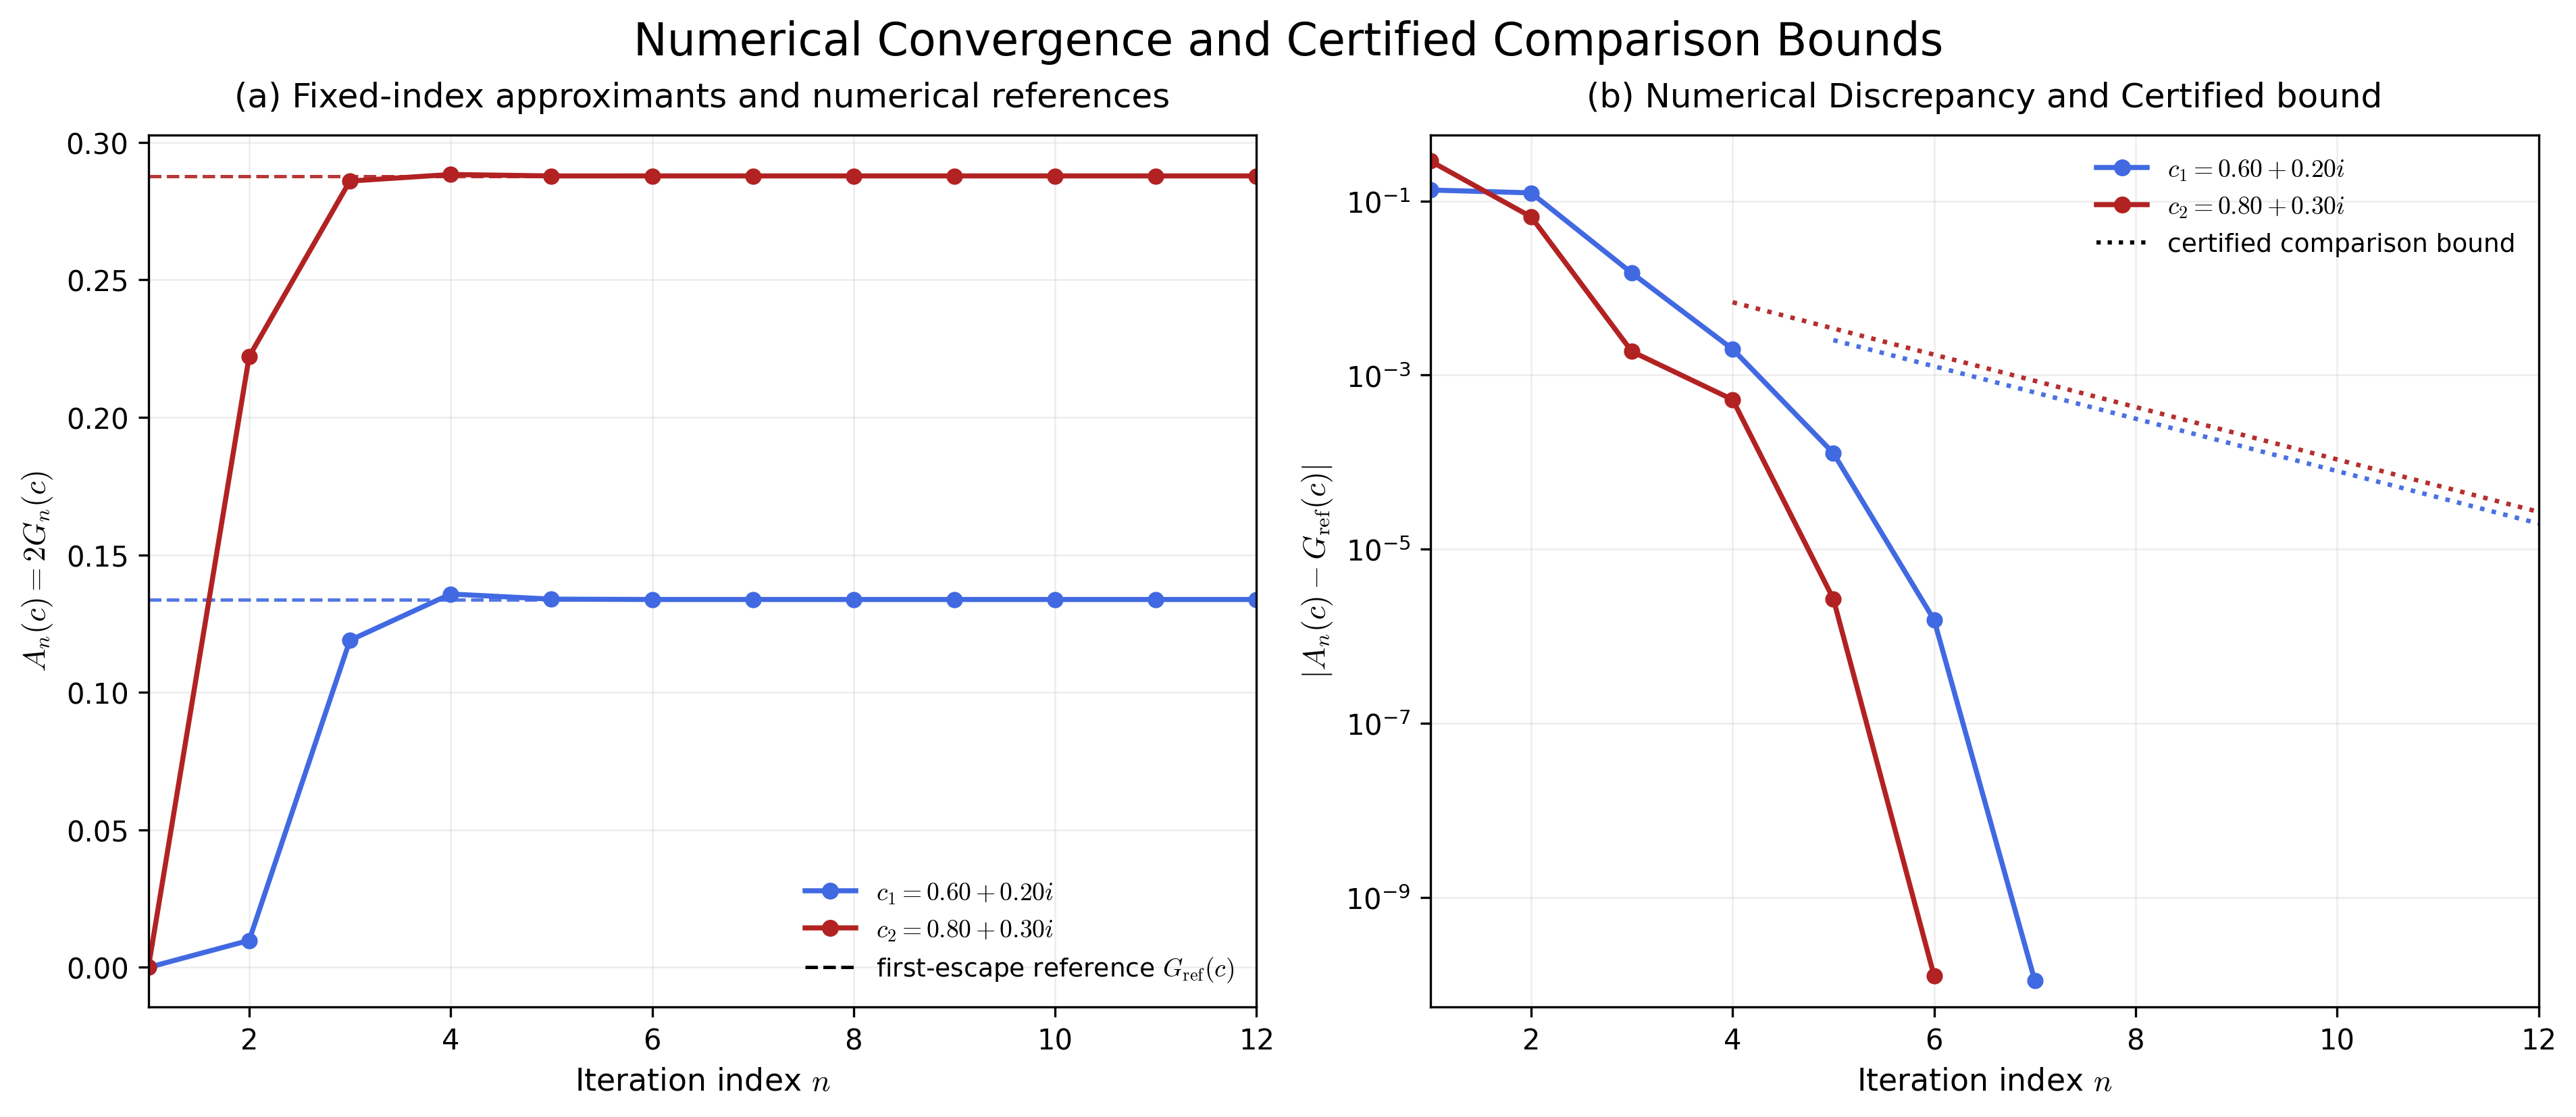

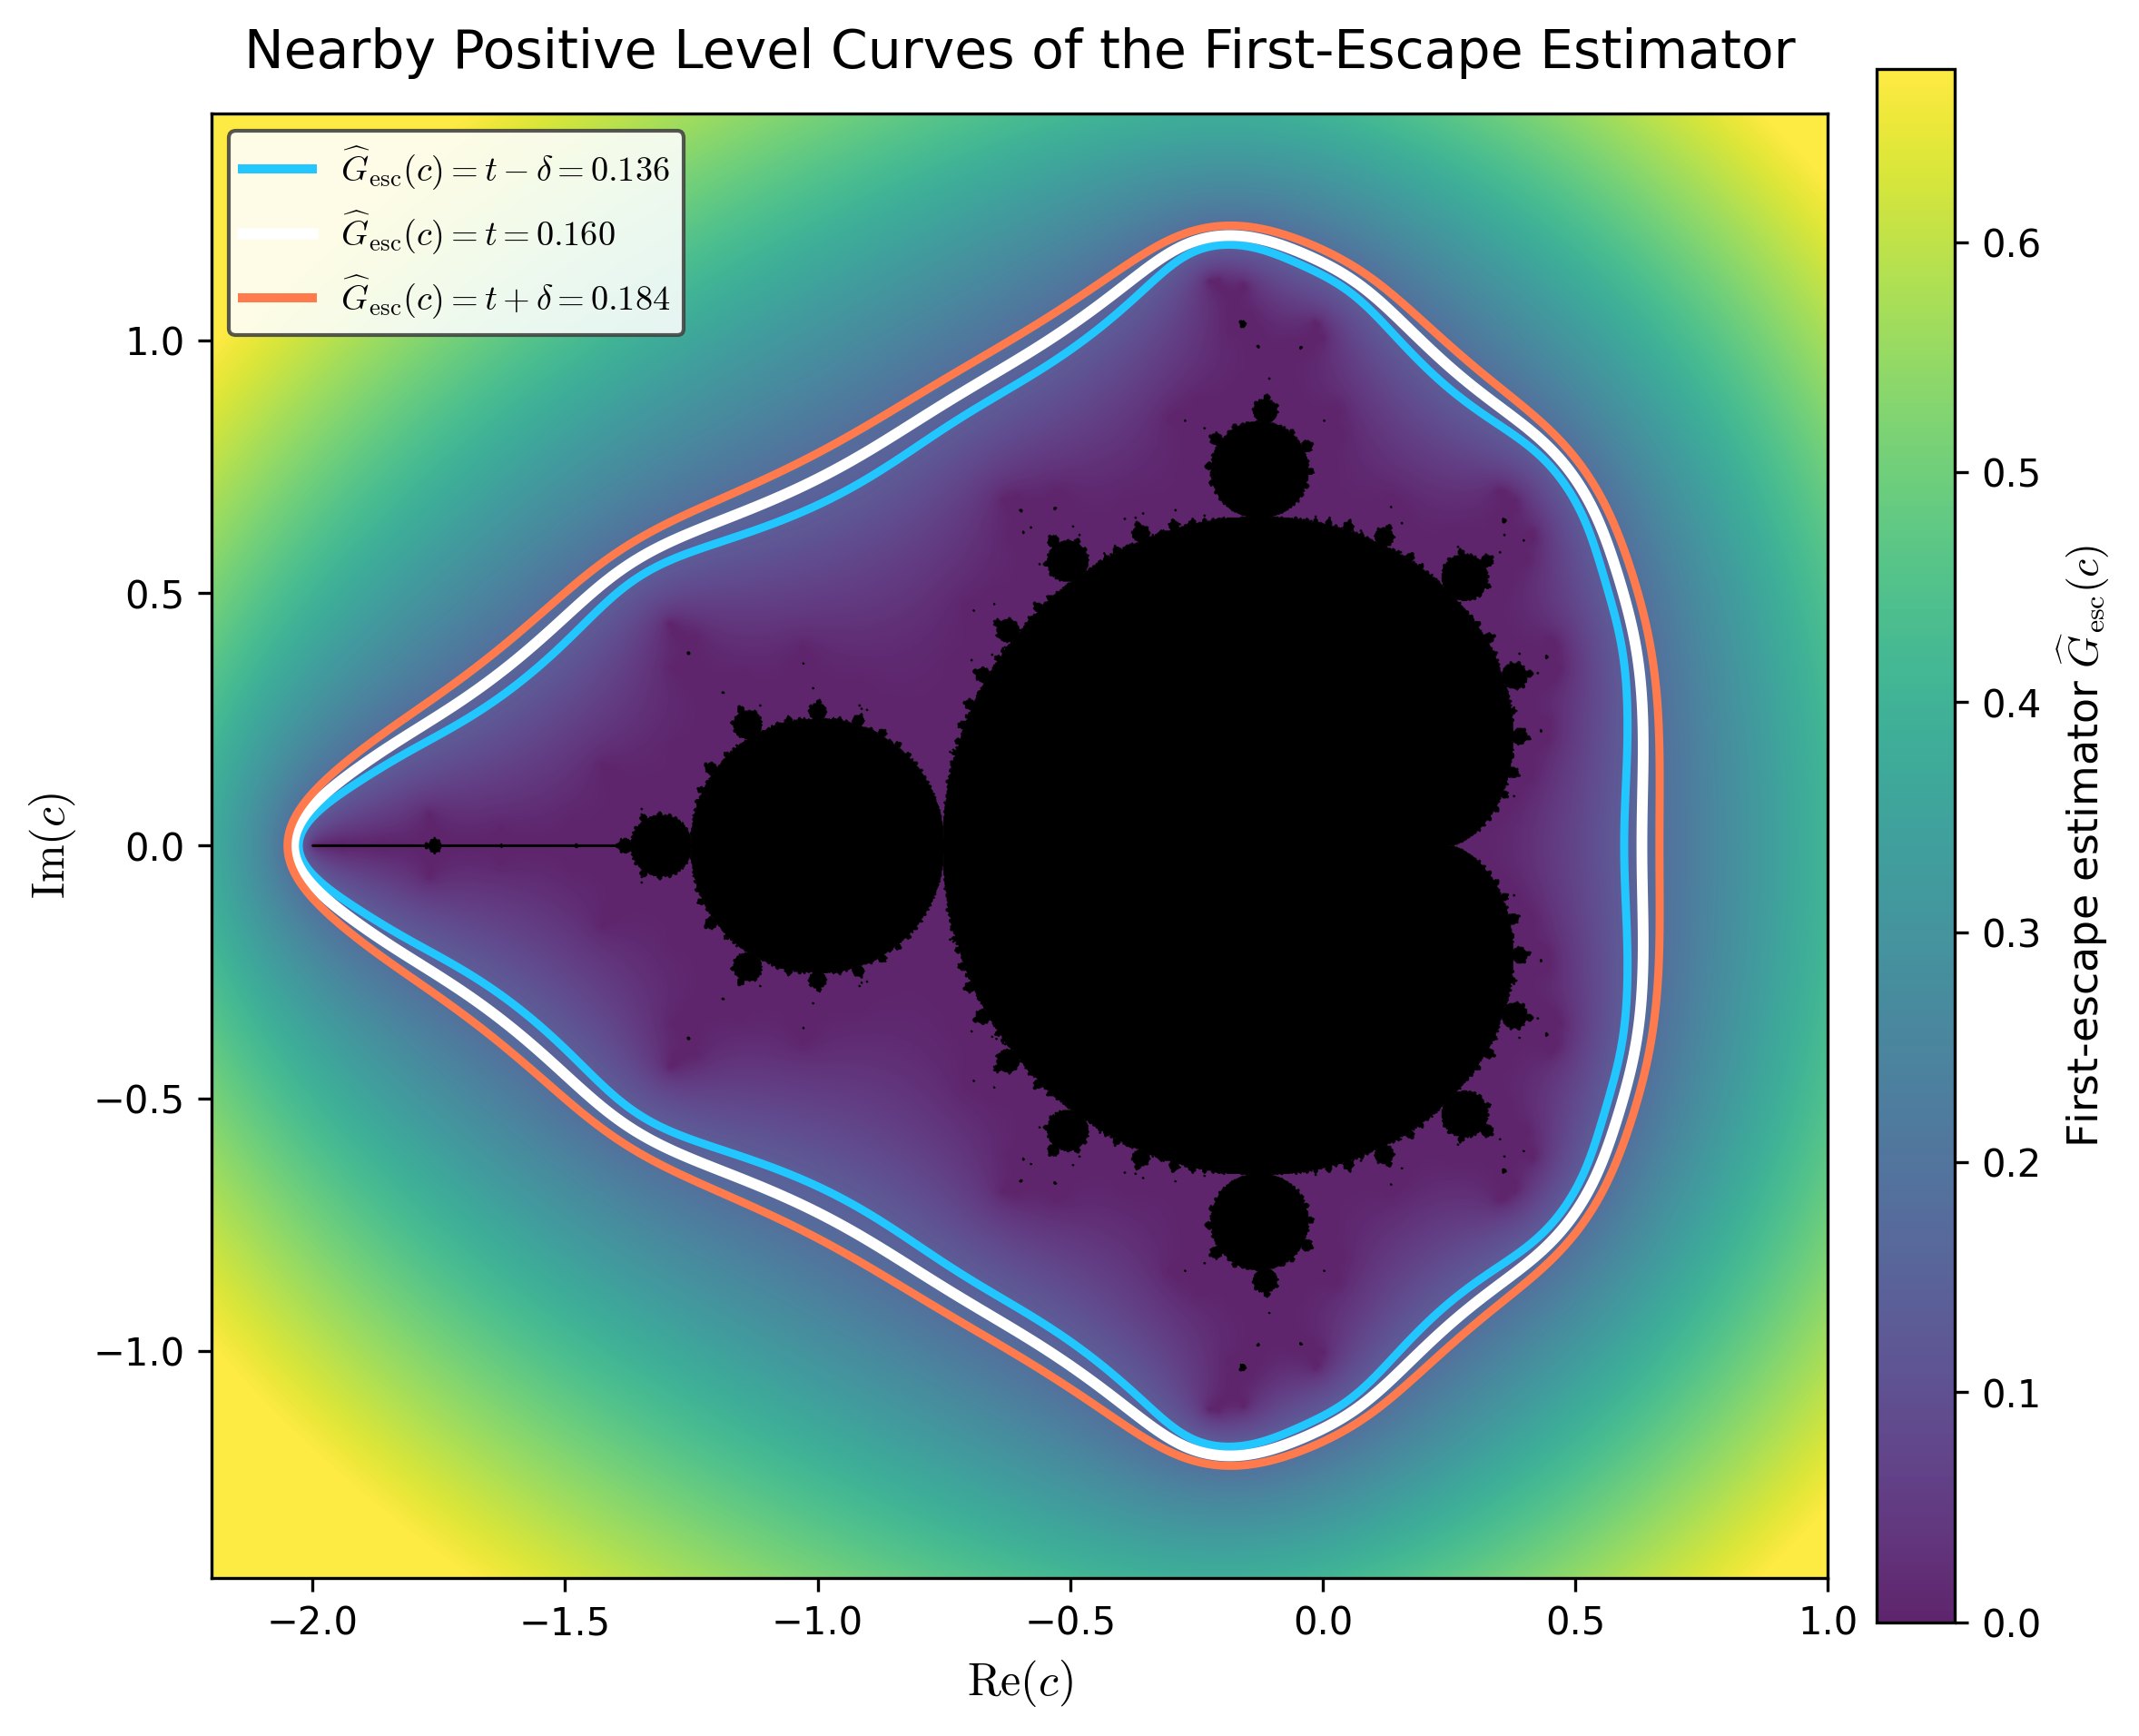

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.lines import Line2D


# =============================================================================
# Global publication-style settings
# =============================================================================

plt.rcParams.update({
    "mathtext.fontset": "cm",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})


# =============================================================================
# Core mathematical routines
# =============================================================================

def positive_log(r):
    """Compute log^+(r) = log(max(r, 1)) for scalars or arrays."""
    return np.log(np.maximum(r, 1.0))


def critical_orbit(c, n_terms=10):
    """Return z_0=0, z_{n+1}=z_n^2+c, through z_{n_terms-1}."""
    z = 0.0 + 0.0j
    orbit = [z]
    for _ in range(n_terms - 1):
        z = z * z + c
        orbit.append(z)
    return np.asarray(orbit, dtype=np.complex128)


def grid_radius_bound(x_min, x_max, y_min, y_max):
    """Maximum |c| over the corners of a rectangular parameter window."""
    corners = [
        x_min + 1j * y_min,
        x_min + 1j * y_max,
        x_max + 1j * y_min,
        x_max + 1j * y_max,
    ]
    return max(abs(corner) for corner in corners)


def check_escape_radius(escape_radius, parameter_modulus_bound):
    """Check R > max{2, sqrt(2 C_G)} for the manuscript error bound."""
    required = max(2.0, np.sqrt(2.0 * parameter_modulus_bound))
    if not escape_radius > required:
        raise ValueError(
            "escape_radius must satisfy "
            f"R > max(2, sqrt(2*C_G)) = {required:.6g}; "
            f"received R = {escape_radius:.6g}."
        )


def dynamical_first_escape_grid(
    c0,
    x_min=-2.0,
    x_max=2.0,
    y_min=-2.0,
    y_max=2.0,
    nx=1200,
    ny=None,
    max_iter=350,
    escape_radius=100.0
):
    """
    Compute a variable-time first-escape approximation to g_{c0}(z).

    For each initial point z, tau(z) is the first index not exceeding
    max_iter for which |f_{c0}^tau(z)(z)| > escape_radius. The returned
    estimator is

        g_hat_esc(z) = 2^{-tau(z)} log |f_{c0}^tau(z)(z)|.

    Points for which escape is not detected are unresolved. Zero is stored
    there only as a display convention; use escaped to distinguish them.
    """
    if ny is None:
        aspect = (y_max - y_min) / (x_max - x_min)
        ny = int(round(nx * aspect))

    x = np.linspace(x_min, x_max, nx, dtype=np.float64)
    y = np.linspace(y_min, y_max, ny, dtype=np.float64)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y

    escaped = np.zeros(Z.shape, dtype=bool)
    escape_time = np.full(Z.shape, -1, dtype=np.int32)
    g_hat = np.zeros(Z.shape, dtype=np.float64)

    for n in range(1, max_iter + 1):
        active = ~escaped
        if not np.any(active):
            break

        Z[active] = Z[active] * Z[active] + c0
        abs_active = np.abs(Z[active])
        newly_escaped_local = abs_active > escape_radius

        if np.any(newly_escaped_local):
            active_rows, active_cols = np.where(active)
            rows = active_rows[newly_escaped_local]
            cols = active_cols[newly_escaped_local]
            abs_new = abs_active[newly_escaped_local]

            g_hat[rows, cols] = np.log(abs_new) / (2.0 ** n)
            escape_time[rows, cols] = n
            escaped[rows, cols] = True
            Z[rows, cols] = 0.0

    return X, Y, g_hat, escape_time, escaped


def parameter_first_escape_grid(
    x_min=-2.2,
    x_max=1.2,
    y_min=-1.4,
    y_max=1.4,
    nx=1500,
    ny=None,
    max_iter=500,
    escape_radius=100.0
):
    """
    Compute the variable-time first-escape estimator of G_M(c).

    For detected parameters,

        G_hat_esc(c) = 2 G_{tau(c)}(c)
                     = 2 log|z_{tau(c)}| / 2^{tau(c)},

    where tau(c) is the first index not exceeding max_iter for which
    |z_tau(c)| > escape_radius.

    This is not the fixed-index field A_N(c)=2G_N(c). The routine also
    returns the pointwise error certificate

        E_hat_esc(c) = 2/2^{tau(c)} *
                       [-log(1-|c|/escape_radius^2)],

    valid under R > max{2, sqrt(2|c|)}. The rectangular-window check below
    enforces this condition uniformly over the grid.

    Unresolved parameters are stored as zero only for display. The escaped
    mask must be used to distinguish them from certified values.
    """
    if ny is None:
        aspect = (y_max - y_min) / (x_max - x_min)
        ny = int(round(nx * aspect))

    c_bound = grid_radius_bound(x_min, x_max, y_min, y_max)
    check_escape_radius(escape_radius, c_bound)

    x = np.linspace(x_min, x_max, nx, dtype=np.float64)
    y = np.linspace(y_min, y_max, ny, dtype=np.float64)
    X, Y = np.meshgrid(x, y)
    C = X + 1j * Y
    Z = np.zeros_like(C, dtype=np.complex128)

    escaped = np.zeros(C.shape, dtype=bool)
    escape_time = np.full(C.shape, -1, dtype=np.int32)
    G_hat = np.zeros(C.shape, dtype=np.float64)
    E_hat = np.full(C.shape, np.nan, dtype=np.float64)

    for n in range(1, max_iter + 1):
        active = ~escaped
        if not np.any(active):
            break

        Z[active] = Z[active] * Z[active] + C[active]
        abs_active = np.abs(Z[active])
        newly_escaped_local = abs_active > escape_radius

        if np.any(newly_escaped_local):
            active_rows, active_cols = np.where(active)
            rows = active_rows[newly_escaped_local]
            cols = active_cols[newly_escaped_local]
            abs_new = abs_active[newly_escaped_local]

            G_hat[rows, cols] = 2.0 * np.log(abs_new) / (2.0 ** n)
            E_hat[rows, cols] = (
                2.0
                / (2.0 ** n)
                * (-np.log1p(-np.abs(C[rows, cols]) / escape_radius ** 2))
            )
            escape_time[rows, cols] = n
            escaped[rows, cols] = True
            Z[rows, cols] = 0.0

    return X, Y, G_hat, E_hat, escape_time, escaped


def two_Gn_sequence(c, N=20):
    """Return the fixed-index sequence A_n(c)=2G_n(c), n=1,...,N."""
    z = 0.0 + 0.0j
    values = []
    for n in range(1, N + 1):
        z = z * z + c
        values.append(2.0 * positive_log(abs(z)) / (2.0 ** n))
    return np.asarray(values, dtype=float)


def first_escape_reference_at_c(c, max_iter=500, escape_radius=1.0e6):
    """
    Return a variable-time first-escape numerical reference for G_M(c).

    Returns
    -------
    value : float
        G_ref(c)=2G_tau(c).
    error_bound : float
        Theorem 8.1 certificate for |G_ref(c)-G_M(c)|.
    escape_time : int
        First index tau with |z_tau| > escape_radius.

    Raises
    ------
    RuntimeError
        If escape is not detected within max_iter.
    """
    check_escape_radius(escape_radius, abs(c))
    z = 0.0 + 0.0j

    for n in range(1, max_iter + 1):
        z = z * z + c
        if abs(z) > escape_radius:
            value = 2.0 * np.log(abs(z)) / (2.0 ** n)
            error_bound = (
                2.0
                / (2.0 ** n)
                * (-np.log1p(-abs(c) / escape_radius ** 2))
            )
            return value, error_bound, n

    raise RuntimeError(
        f"Escape was not detected for c={c!r} within {max_iter} iterations."
    )


def first_entry_time_and_bounds(c, N, radius):
    """
    Return the first entry time n0 into |z|>=radius and Theorem 8.1 bounds.

    The returned array contains NaN before n0 and the explicit bound for
    n>=n0.
    """
    check_escape_radius(radius, abs(c))
    z = 0.0 + 0.0j
    n0 = None

    for n in range(1, N + 1):
        z = z * z + c
        if n0 is None and abs(z) >= radius:
            n0 = n

    bounds = np.full(N, np.nan, dtype=float)
    if n0 is not None:
        constant = 2.0 * (-np.log1p(-abs(c) / radius ** 2))
        n_values = np.arange(n0, N + 1)
        bounds[n0 - 1:] = constant / (2.0 ** n_values)

    return n0, bounds


# =============================================================================
# Figure 1 in the manuscript: dynamical-plane vs parameter-plane comparison
# =============================================================================

def make_figure_dynamical_vs_parameter(
    output_name="figure1_dynamical_vs_parameter_plane_refined.png"
):
    """Create the dynamical-plane and parameter-plane comparison figure."""
    c0 = 0.35 + 0.60j

    dyn_xmin, dyn_xmax = -2.0, 2.0
    dyn_ymin, dyn_ymax = -2.0, 2.0
    par_xmin, par_xmax = -2.2, 1.2
    par_ymin, par_ymax = -1.4, 1.4

    Xd, Yd, g_dyn, dyn_tau, dyn_escaped = dynamical_first_escape_grid(
        c0,
        x_min=dyn_xmin,
        x_max=dyn_xmax,
        y_min=dyn_ymin,
        y_max=dyn_ymax,
        nx=1200,
        max_iter=350,
        escape_radius=100.0
    )

    Xp, Yp, G_par, E_par, par_tau, par_escaped = parameter_first_escape_grid(
        x_min=par_xmin,
        x_max=par_xmax,
        y_min=par_ymin,
        y_max=par_ymax,
        nx=1500,
        max_iter=500,
        escape_radius=100.0
    )

    orbit = critical_orbit(c0, n_terms=8)
    orbit_x = orbit.real
    orbit_y = orbit.imag

    G_ref_c0, _, _ = first_escape_reference_at_c(
        c0,
        max_iter=500,
        escape_radius=1.0e6
    )

    fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.6), dpi=240)

    # -------------------------------------------------------------------------
    # Left panel: dynamical plane
    # -------------------------------------------------------------------------
    ax = axes[0]
    g_display = np.ma.masked_where(~dyn_escaped, g_dyn)

    im1 = ax.imshow(
        g_display,
        extent=[dyn_xmin, dyn_xmax, dyn_ymin, dyn_ymax],
        origin="lower",
        cmap="viridis",
        aspect="equal",
        interpolation="bilinear"
    )

    unresolved_dyn = (~dyn_escaped).astype(float)
    ax.contourf(
        Xd,
        Yd,
        unresolved_dyn,
        levels=[0.5, 1.5],
        colors=["black"]
    )

    dyn_levels = [0.20, 0.40, 0.80]
    CS1 = ax.contour(
        Xd,
        Yd,
        g_dyn,
        levels=dyn_levels,
        colors="white",
        linewidths=0.9,
        alpha=0.95
    )
    ax.clabel(
        CS1,
        inline=True,
        fontsize=8,
        fmt=lambda v: rf"$\widehat g_{{\rm esc}}={v:.2f}$"
    )

    ax.plot(orbit_x, orbit_y, color="red", linewidth=1.0, alpha=0.75, zorder=5)
    ax.scatter(orbit_x, orbit_y, color="red", s=16, zorder=6)

    label_specs = {
        0: {"text": r"$0$", "offset": (0.04, 0.08)},
        1: {"text": r"$c_0$", "offset": (0.09, 0.03)},
        2: {"text": r"$f_{c_0}^{\circ 2}(0)$", "offset": (0.08, 0.10)}
    }

    for idx, spec in label_specs.items():
        dx, dy = spec["offset"]
        ax.annotate(
            spec["text"],
            xy=(orbit_x[idx], orbit_y[idx]),
            xytext=(orbit_x[idx] + dx, orbit_y[idx] + dy),
            color="white",
            fontsize=8,
            bbox=dict(facecolor="black", alpha=0.35, edgecolor="none", pad=1.6),
            arrowprops=dict(arrowstyle="-", color="white", lw=0.6, alpha=0.7)
        )

    ax.set_title(r"Dynamical plane for $f_{c_0}(z)=z^2+c_0$", pad=8)
    ax.set_xlabel(r"$\operatorname{Re}(z)$")
    ax.set_ylabel(r"$\operatorname{Im}(z)$")
    ax.set_xlim(dyn_xmin, dyn_xmax)
    ax.set_ylim(dyn_ymin, dyn_ymax)
    ax.set_aspect("equal")

    cbar1 = fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)
    cbar1.set_label(r"First-escape approximation $\widehat g_{\rm esc}(z)$")

    # -------------------------------------------------------------------------
    # Right panel: parameter plane
    # -------------------------------------------------------------------------
    ax = axes[1]
    G_display = np.ma.masked_where(~par_escaped, G_par)

    im2 = ax.imshow(
        G_display,
        extent=[par_xmin, par_xmax, par_ymin, par_ymax],
        origin="lower",
        cmap="magma",
        aspect="equal",
        interpolation="bilinear"
    )

    unresolved_par = (~par_escaped).astype(float)
    ax.contourf(
        Xp,
        Yp,
        unresolved_par,
        levels=[0.5, 1.5],
        colors=["black"]
    )

    par_levels = [0.20, 0.40, 0.80]
    if G_ref_c0 > 0.05 and all(abs(G_ref_c0 - lv) > 0.03 for lv in par_levels):
        par_levels.append(G_ref_c0)
    par_levels = sorted(par_levels)

    color_list = ["cyan", "deepskyblue", "springgreen", "white"]
    CS2 = ax.contour(
        Xp,
        Yp,
        G_par,
        levels=par_levels,
        colors=color_list[:len(par_levels)],
        linewidths=1.1,
        alpha=0.95
    )
    ax.clabel(
        CS2,
        inline=True,
        fontsize=8,
        fmt=lambda v: rf"$\widehat G_{{\rm esc}}={v:.2f}$"
    )

    ax.scatter([c0.real], [c0.imag], color="red", s=32, zorder=6)
    ax.annotate(
        r"$c_0$",
        xy=(c0.real, c0.imag),
        xytext=(c0.real + 0.07, c0.imag + 0.07),
        color="white",
        fontsize=9,
        bbox=dict(facecolor="black", alpha=0.35, edgecolor="none", pad=1.6)
    )

    ax.set_title(r"Parameter plane: unresolved mask and parameter $c_0$", pad=8)
    ax.set_xlabel(r"$\operatorname{Re}(c)$")
    ax.set_ylabel(r"$\operatorname{Im}(c)$")
    ax.set_xlim(par_xmin, par_xmax)
    ax.set_ylim(par_ymin, par_ymax)
    ax.set_aspect("equal")

    cbar2 = fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
    cbar2.set_label(r"First-escape estimator $\widehat G_{\rm esc}(c)$")

    fig.suptitle(
        rf"Dynamical-plane vs parameter-plane comparison for "
        rf"$c_0={c0.real:.2f}+{c0.imag:.2f}i$",
        fontsize=14,
        y=0.98
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(output_name, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()


# =============================================================================
# Figure 2 in the manuscript: exterior uniformization schematic
# =============================================================================

def bezier_curve(P0, P1, P2, P3, n=300):
    """Cubic Bezier curve for a schematic external ray."""
    t = np.linspace(0, 1, n)[:, None]
    curve = (
        ((1 - t) ** 3) * P0
        + 3 * ((1 - t) ** 2) * t * P1
        + 3 * (1 - t) * (t ** 2) * P2
        + (t ** 3) * P3
    )
    return curve[:, 0], curve[:, 1]


def make_figure_uniformization_schematic(
    output_name="figure2_uniformization_schematic_refined.png"
):
    """
    Create a schematic figure of the exterior uniformization.

    The left background is a variable-time first-escape display. The red ray
    is schematic and is not computed by numerical inversion of Phi_M.
    """
    xmin, xmax = -2.2, 1.2
    ymin, ymax = -1.4, 1.4

    X, Y, G_hat, _, _, escaped = parameter_first_escape_grid(
        x_min=xmin,
        x_max=xmax,
        y_min=ymin,
        y_max=ymax,
        nx=1400,
        max_iter=450,
        escape_radius=100.0
    )

    levels_all = [0.30, 0.70, 1.20]
    highlight_t = 0.70
    thin_levels = [lv for lv in levels_all if lv != highlight_t]
    theta = np.pi / 4

    fig = plt.figure(figsize=(15, 6.2), dpi=240, layout="constrained")
    gs = fig.add_gridspec(1, 3, width_ratios=[1.05, 0.24, 1.0])
    axL = fig.add_subplot(gs[0, 0])
    axM = fig.add_subplot(gs[0, 1])
    axR = fig.add_subplot(gs[0, 2])

    # -------------------------------------------------------------------------
    # Left panel
    # -------------------------------------------------------------------------
    G_display = np.ma.masked_where(~escaped, G_hat)
    axL.imshow(
        G_display,
        extent=[xmin, xmax, ymin, ymax],
        origin="lower",
        cmap="magma",
        aspect="equal",
        interpolation="bilinear"
    )

    unresolved = (~escaped).astype(float)
    axL.contourf(X, Y, unresolved, levels=[0.5, 1.5], colors=["black"])
    axL.contour(
        X, Y, G_hat, levels=thin_levels,
        colors="#d0d0d0", linewidths=0.85, alpha=0.90
    )
    axL.contour(
        X, Y, G_hat, levels=[highlight_t],
        colors="blue", linewidths=1.6
    )

    P0 = np.array([0.97, 1.02])
    P1 = np.array([0.82, 0.84])
    P2 = np.array([0.63, 0.55])
    P3 = np.array([0.40, 0.28])
    ray_x, ray_y = bezier_curve(P0, P1, P2, P3, n=300)
    axL.plot(
        ray_x, ray_y, color="red", lw=2.0,
        linestyle="--", solid_capstyle="round", alpha=0.95
    )

    axL.text(0.68, 1.10, r"$E_t$", color="blue", fontsize=12)
    axL.text(0.64, 0.80, r"$\mathcal{R}_\theta$", color="red", fontsize=12)
    axL.text(
        0.02, 0.98, r"(a)", transform=axL.transAxes,
        ha="left", va="top", fontsize=12
    )
    axL.set_title(r"Parameter plane: $\mathbb{C}\setminus\mathcal{M}$", pad=8)
    axL.set_xlabel(r"$\operatorname{Re}(c)$")
    axL.set_ylabel(r"$\operatorname{Im}(c)$")
    axL.set_xlim(xmin, xmax)
    axL.set_ylim(ymin, ymax)
    axL.set_aspect("equal")

    # -------------------------------------------------------------------------
    # Middle panel
    # -------------------------------------------------------------------------
    axM.axis("off")
    axM.annotate(
        "",
        xy=(0.92, 0.5),
        xytext=(0.08, 0.5),
        arrowprops=dict(arrowstyle="->", lw=2.5, color="black")
    )
    axM.text(0.5, 0.58, r"$\Phi_{\mathcal{M}}$", ha="center", va="center", fontsize=16)
    axM.text(0.5, 0.40, "conformal", ha="center", va="center", fontsize=10)

    # -------------------------------------------------------------------------
    # Right panel
    # -------------------------------------------------------------------------
    axR.set_aspect("equal")
    unit_disk = Circle((0, 0), 1.0, facecolor="black", edgecolor="black", lw=1.1)
    axR.add_patch(unit_disk)

    for lv in thin_levels:
        axR.add_patch(Circle((0, 0), np.exp(lv), fill=False, ec="#d0d0d0", lw=0.9))

    r_high = np.exp(highlight_t)
    axR.add_patch(Circle((0, 0), r_high, fill=False, ec="blue", lw=1.6))

    r_vals = np.linspace(1.0, 2.2, 220)
    wx = r_vals * np.cos(theta)
    wy = r_vals * np.sin(theta)
    axR.plot(wx, wy, color="red", lw=2.0)

    axR.text(1.26, 0.67, r"$|w|=e^t$", color="blue", fontsize=10)
    axR.text(
        1.62 * np.cos(theta) - 0.55,
        1.62 * np.sin(theta) + 0.02,
        r"$\arg w=\theta$",
        color="red",
        fontsize=10,
        ha="right",
        va="center"
    )
    axR.text(
        0, 0, r"$\overline{\mathbb{D}}$",
        color="white", fontsize=14, ha="center", va="center"
    )
    axR.text(
        0.02, 0.98, r"(b)", transform=axR.transAxes,
        ha="left", va="top", fontsize=12
    )
    axR.set_title(r"Exterior disk: $\mathbb{C}\setminus\overline{\mathbb{D}}$", pad=8)
    axR.set_xlabel(r"$\operatorname{Re}(w)$")
    axR.set_ylabel(r"$\operatorname{Im}(w)$")
    axR.set_xlim(-2.2, 2.2)
    axR.set_ylim(-2.2, 2.2)

    fig.savefig(output_name, dpi=300, facecolor="white")
    plt.show()


# =============================================================================
# Figure 3 in the manuscript: parameter first-escape heat map
# =============================================================================

def make_figure_green_heatmap(
    output_name="figure3_green_function_heatmap_refined.png"
):
    """Create a heat map of the variable-time first-escape estimator."""
    xmin, xmax = -2.2, 1.2
    ymin, ymax = -1.4, 1.4

    X, Y, G_hat, E_hat, escape_time, escaped = parameter_first_escape_grid(
        x_min=xmin,
        x_max=xmax,
        y_min=ymin,
        y_max=ymax,
        nx=1600,
        max_iter=500,
        escape_radius=100.0
    )

    fig, ax = plt.subplots(figsize=(9.0, 7.0), dpi=240)
    G_display = np.ma.masked_where(~escaped, G_hat)

    im = ax.imshow(
        G_display,
        extent=[xmin, xmax, ymin, ymax],
        origin="lower",
        cmap="magma",
        aspect="equal",
        interpolation="bilinear"
    )

    unresolved = (~escaped).astype(float)
    ax.contourf(X, Y, unresolved, levels=[0.5, 1.5], colors=["black"])

    thin_levels = [0.20, 0.40, 1.20]
    highlight_level = 0.70

    CS_thin = ax.contour(
        X, Y, G_hat, levels=thin_levels,
        colors="#d8d8d8", linewidths=0.9
    )
    CS_high = ax.contour(
        X, Y, G_hat, levels=[highlight_level],
        colors="royalblue", linewidths=1.3
    )

    ax.clabel(
        CS_thin,
        levels=[0.20, 0.40],
        inline=True,
        fontsize=8,
        fmt=lambda v: rf"$\widehat G_{{\rm esc}}={v:.2f}$"
    )
    ax.clabel(
        CS_high,
        inline=True,
        fontsize=8,
        fmt=lambda v: rf"$\widehat G_{{\rm esc}}={v:.2f}$"
    )

    ax.set_xlabel(r"$\operatorname{Re}(c)$")
    ax.set_ylabel(r"$\operatorname{Im}(c)$")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r"First-escape estimator $\widehat G_{\rm esc}(c)$")

    fig.savefig(output_name, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()


# =============================================================================
# Figure 5 in the manuscript: quantitative-conformal bridge convergence
# =============================================================================

def make_figure_convergence_bridge(
    output_name="figure5_convergence_bridge_refined.png"
):
    """
    Plot A_n(c)=2G_n(c), a first-escape numerical reference, and the explicit
    Theorem 8.1 upper bound after entry into a prescribed escape region.
    """
    params = [0.60 + 0.20j, 0.80 + 0.30j]
    labels = [r"$c_1=0.60+0.20i$", r"$c_2=0.80+0.30i$"]
    colors = ["royalblue", "firebrick"]

    N = 12
    n_vals = np.arange(1, N + 1)
    theorem_radius = 4.0
    reference_radius = 1.0e6

    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(12.6, 5.4), dpi=300, constrained_layout=True
    )
    fig.suptitle(
        r"Numerical Convergence and Certified Comparison Bounds",
        fontsize=16
    )

    sequence_handles = [
        Line2D([0], [0], color=col, marker="o", lw=1.8, ms=5, label=lab)
        for lab, col in zip(labels, colors)
    ]
    reference_handle = Line2D(
        [0], [0], color="black", linestyle="--", lw=1.2,
        label=r"first-escape reference $G_{\rm ref}(c)$"
    )
    bound_handle = Line2D(
        [0], [0], color="black", linestyle=":", lw=1.5,
        label=r"certified comparison bound"
    )

    all_discrepancies = []
    all_bounds = []

    for c, lab, col in zip(params, labels, colors):
        seq = two_Gn_sequence(c, N=N)
        reference, reference_error, reference_tau = first_escape_reference_at_c(
            c, max_iter=500, escape_radius=reference_radius
        )
        n0, theorem_bounds = first_entry_time_and_bounds(c, N=N, radius=theorem_radius)
        comparison_bounds = theorem_bounds + reference_error
        discrepancy = np.abs(seq - reference)
        discrepancy_plot = np.where(discrepancy > 0.0, discrepancy, np.nan)

        all_discrepancies.append(discrepancy_plot)
        all_bounds.append(comparison_bounds)

        ax1.plot(n_vals, seq, color=col, marker="o", ms=4.8, lw=1.8)
        ax1.hlines(
            reference, xmin=1, xmax=N, colors=col,
            linestyles="--", linewidth=1.2, alpha=0.9
        )

        ax2.semilogy(
            n_vals, discrepancy_plot, color=col,
            marker="o", ms=4.8, lw=1.8, label=lab
        )
        if n0 is not None:
            ax2.semilogy(
                n_vals, comparison_bounds, color=col,
                linestyle=":", linewidth=1.6, alpha=0.95
            )

        print(f"{lab}: G_ref(c) = {reference:.12g}")
        print(f"{lab}: reference escape time = {reference_tau}")
        print(f"{lab}: reference error certificate" f"<= {reference_error:.6e}")
        print(f"{lab}: theorem-bound entry time for" f"R={theorem_radius:g} is n0={n0}")
        print(f"{lab}: discrepancies = {discrepancy}")
        print(f"{lab}: theorem bounds = {theorem_bounds}")
        print(f"{lab}: certified comparison bounds = {comparison_bounds}")


    ax1.set_title(r"(a) Fixed-index approximants and numerical references", fontsize=12, pad=10)
    ax1.set_xlabel(r"Iteration index $n$")
    ax1.set_ylabel(r"$A_n(c)=2G_n(c)$")
    ax1.set_xlim(1, N)
    ax1.grid(alpha=0.22, linewidth=0.6)
    ax1.legend(
        handles=sequence_handles + [reference_handle],
        frameon=False, fontsize=9, loc="lower right"
    )

    ax2.set_title(r"(b) Numerical Discrepancy and Certified bound", fontsize=12, pad=10)
    ax2.set_xlabel(r"Iteration index $n$")
    ax2.set_ylabel(r"$|A_n(c)-G_{\rm ref}(c)|$")
    ax2.set_xlim(1, N)
    ax2.grid(which="both", alpha=0.22, linewidth=0.6)
    ax2.legend(
        handles=sequence_handles + [bound_handle],
        frameon=False, fontsize=9, loc="upper right"
    )

    finite_values = []
    for array in all_discrepancies + all_bounds:
        values = array[np.isfinite(array) & (array > 0)]
        if values.size:
            finite_values.append(values)
    if finite_values:
        merged = np.concatenate(finite_values)
        ax2.set_ylim(max(np.min(merged) * 0.5, 1.0e-18), np.max(merged) * 2.0)

    fig.savefig(output_name, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()


# =============================================================================
# Figure 6 in the manuscript: nearby first-escape level curves
# =============================================================================

def make_figure_nearby_equipotential_stability(
    output_png="nearby_equipotential_stability_improved.png",
    output_pdf="nearby_equipotential_stability_improved.pdf"
):
    """
    Create a finite-resolution illustration of nearby positive level curves
    of the variable-time first-escape estimator.

    The exact Hausdorff-continuity theorem concerns equipotentials of G_M.
    This figure is only a numerical illustration and is not used in the proof.
    """
    x_min, x_max = -2.2, 1.0
    y_min, y_max = -1.45, 1.45

    X, Y, G_hat, E_hat, escape_time, escaped = parameter_first_escape_grid(
        x_min=x_min,
        x_max=x_max,
        y_min=y_min,
        y_max=y_max,
        nx=1500,
        max_iter=650,
        escape_radius=200.0
    )

    level = 0.160
    delta = 0.024
    levels = [level - delta, level, level + delta]

    fig, ax = plt.subplots(figsize=(8.2, 7.2), dpi=300)
    extent = [X.min(), X.max(), Y.min(), Y.max()]

    G_background = np.ma.masked_where(~escaped, G_hat)
    vmax = np.nanpercentile(G_hat[escaped], 97) if np.any(escaped) else 0.8

    background = ax.imshow(
        G_background,
        extent=extent,
        origin="lower",
        cmap="viridis",
        interpolation="bilinear",
        vmin=0.0,
        vmax=vmax,
        alpha=0.86
    )

    unresolved = (~escaped).astype(float)
    ax.contourf(
        X, Y, unresolved, levels=[0.5, 1.5],
        colors=["black"], alpha=1.0, antialiased=True
    )
    ax.contour(
        X, Y, unresolved, levels=[0.5],
        colors=["black"], linewidths=0.45, alpha=0.95
    )

    contour_colors = ["#22C7FF", "white", "#FF7A4D"]
    contour_widths = [2.15, 2.85, 2.15]
    ax.contour(
        X, Y, G_hat, levels=levels,
        colors=contour_colors,
        linewidths=contour_widths,
        antialiased=True
    )

    legend_handles = [
        Line2D(
            [0], [0], color=contour_colors[0], lw=2.4,
            label=rf"$\widehat G_{{\rm esc}}(c)=t-\delta={levels[0]:.3f}$"
        ),
        Line2D(
            [0], [0], color=contour_colors[1], lw=3.0,
            label=rf"$\widehat G_{{\rm esc}}(c)=t={levels[1]:.3f}$"
        ),
        Line2D(
            [0], [0], color=contour_colors[2], lw=2.4,
            label=rf"$\widehat G_{{\rm esc}}(c)=t+\delta={levels[2]:.3f}$"
        )
    ]

    ax.legend(
        handles=legend_handles,
        loc="upper left",
        fontsize=9.2,
        frameon=True,
        framealpha=0.88,
        facecolor="white",
        edgecolor="0.25"
    )

    cbar = fig.colorbar(background, ax=ax, shrink=0.84, pad=0.025)
    cbar.set_label(r"First-escape estimator $\widehat G_{\rm esc}(c)$", fontsize=11)

    ax.set_title("Nearby Positive Level Curves of the First-Escape Estimator", fontsize=14, pad=12)
    ax.set_xlabel(r"$\operatorname{Re}(c)$", fontsize=12)
    ax.set_ylabel(r"$\operatorname{Im}(c)$", fontsize=12)
    ax.set_xlim(X.min(), X.max())
    ax.set_ylim(Y.min(), Y.max())
    ax.set_aspect("equal", adjustable="box")
    ax.grid(False)

    plt.tight_layout()
    fig.savefig(output_png, dpi=300, bbox_inches="tight")
    fig.savefig(output_pdf, bbox_inches="tight")
    plt.show()


# =============================================================================
# Run all figures
# =============================================================================

if __name__ == "__main__":
    make_figure_dynamical_vs_parameter(
        output_name="figure1_dynamical_vs_parameter_plane_refined.png"
    )

    make_figure_uniformization_schematic(
        output_name="figure2_uniformization_schematic_refined.png"
    )

    make_figure_green_heatmap(
        output_name="figure3_green_function_heatmap_refined.png"
    )

    make_figure_convergence_bridge(
        output_name="figure5_convergence_bridge_refined.png"
    )

    make_figure_nearby_equipotential_stability(
        output_png="nearby_equipotential_stability_improved.png",
        output_pdf="nearby_equipotential_stability_improved.pdf"
    )
